# XGBoost on the Higgs Boson Dataset


## Table of Contents
0. Setup
1. Dataset Introduction
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Default XGBoost Model
5. Hyperparameter Tuning (5.6: how each hyperparameter affects the model)
6. Model Evaluation (6.6: overfitting check, 6.7: decision threshold and AMS)
7. Feature Importance and Interpretation (7.5: inside one tree, 7.6: explaining one prediction)
8. Comparison with Other Algorithms (8.3b: LightGBM, 8.7: improving the model, 8.8: regression, 8.9: saving the model)
9. Conclusions
10. References

## 0. Setup

### 0.1 Imports
- pandas, numpy, matplotlib, seaborn
- xgboost
- sklearn: model_selection, metrics, linear_model, ensemble
- shap, time

In [1]:
import os
import json
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
import shap
from scipy.stats import randint, uniform, loguniform

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             precision_recall_curve, mean_absolute_error, mean_squared_error, r2_score)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import PartialDependenceDisplay 

warnings.filterwarnings("ignore")
import lightgbm
print("xgboost", xgb.__version__, "| lightgbm", lightgbm.__version__, "| shap", shap.__version__)

xgboost 3.2.0 | lightgbm 4.7.0 | shap 0.51.0


C:\Users\Hello\Desktop\NTI\Assigments\Assigemnt 7 _ XGBoost\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0.2 Settings
- random seed
- plot style


In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print(f"Random seed: {RANDOM_STATE}")
print("Plot style configured.")

Random seed: 42
Plot style configured.


## 1. Dataset Introduction

### 1.1 Load the data
- read the .csv.gz directly with pandas

In [3]:
DATA_PATH = "atlas-higgs-challenge-2014-v2.csv.gz"

df_all = pd.read_csv(DATA_PATH)   # pandas unzips .gz automatically
print(f"Rows: {df_all.shape[0]:,} | Columns: {df_all.shape[1]}")
df_all.head()

Rows: 818,238 | Columns: 35


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333


### 1.2 About the dataset
- Source: CERN Open Data record 328 (ATLAS, 2014)
- 818,238 simulated events, 30 features
- Target: `Label` → s (signal) / b (background)
- Extra columns: EventId, Weight, KaggleSet, KaggleWeight

In [4]:
der_cols   = [c for c in df_all.columns if c.startswith("DER_")]
pri_cols   = [c for c in df_all.columns if c.startswith("PRI_")]
other_cols = [c for c in df_all.columns if c not in der_cols + pri_cols]

print(f"DER_ (derived) features : {len(der_cols)}")
print(f"PRI_ (primitive) features: {len(pri_cols)}")
print(f"Other columns            : {other_cols}")

DER_ (derived) features : 13
PRI_ (primitive) features: 17
Other columns            : ['EventId', 'Weight', 'Label', 'KaggleSet', 'KaggleWeight']


### 1.3 Feature groups
- `PRI_` = primitive (measured directly by the detector)
- `DER_` = derived (computed by physicists from PRI_)
- `PRI_jet_num` = number of jets (0–3)

In [5]:
print("DER_ features:")
print(der_cols)
print()
print("PRI_ features:")
print(pri_cols)

DER_ features:
['DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality', 'DER_lep_eta_centrality']

PRI_ features:
['PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi', 'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi', 'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt']


### 1.4 Keep the original training set
- filter `KaggleSet == 't'` → 250,000 rows
- why: same data the 2014 competition used

In [6]:
print(df_all["KaggleSet"].value_counts())
print()

df = df_all[df_all["KaggleSet"] == "t"].reset_index(drop=True)
print(f"Training set: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df["Label"].value_counts(normalize=True).round(3))

KaggleSet
v    450000
t    250000
b    100000
u     18238
Name: count, dtype: int64

Training set: 250,000 rows x 35 columns
Label
b    0.657
s    0.343
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)

### 2.1 Shape, data types, first rows

In [7]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print(df.dtypes.value_counts())
print()
df.info()

Shape: 250,000 rows x 35 columns

float64    31
int64       2
str         2
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   EventId                      250000 non-null  int64  
 1   DER_mass_MMC                 250000 non-null  float64
 2   DER_mass_transverse_met_lep  250000 non-null  float64
 3   DER_mass_vis                 250000 non-null  float64
 4   DER_pt_h                     250000 non-null  float64
 5   DER_deltaeta_jet_jet         250000 non-null  float64
 6   DER_mass_jet_jet             250000 non-null  float64
 7   DER_prodeta_jet_jet          250000 non-null  float64
 8   DER_deltar_tau_lep           250000 non-null  float64
 9   DER_pt_tot                   250000 non-null  float64
 10  DER_sum_pt                   250000 non-null  float64
 11  DER_pt_ratio_lep_tau     

In [8]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
EventId,250000.0,224999.50,72168.93,100000.00,162499.75,224999.50,287499.25,349999.00
DER_mass_MMC,250000.0,-49.02,406.35,-999.00,78.10,105.01,130.61,1192.03
DER_mass_transverse_met_lep,250000.0,49.24,35.34,0.00,19.24,46.52,73.60,690.08
DER_mass_vis,250000.0,81.18,40.83,6.33,59.39,73.75,92.26,1349.35
DER_pt_h,250000.0,57.90,63.66,0.00,14.07,38.47,79.17,2835.00
DER_deltaeta_jet_jet,250000.0,-708.42,454.48,-999.00,-999.00,-999.00,0.49,8.50
DER_mass_jet_jet,250000.0,-601.24,657.97,-999.00,-999.00,-999.00,83.45,4974.98
DER_prodeta_jet_jet,250000.0,-709.36,453.02,-999.00,-999.00,-999.00,-4.59,16.69
DER_deltar_tau_lep,250000.0,2.37,0.78,0.21,1.81,2.49,2.96,5.68
DER_pt_tot,250000.0,18.92,22.27,0.00,2.84,12.32,27.59,2835.00


### 2.2 Target distribution
- count + % of s vs b
- is it imbalanced?

        count  percent
Label                 
b      164333     65.7
s       85667     34.3


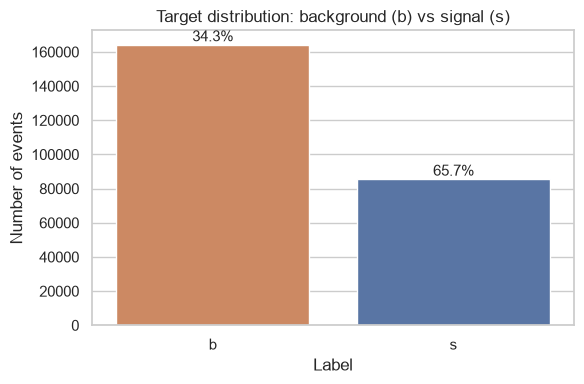

In [9]:
counts = df["Label"].value_counts()
pcts = df["Label"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "percent": pcts.round(1)}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Label", order=["b", "s"], hue="Label", palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
for p, pct in zip(ax.patches, pcts[["b", "s"]]):
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
ax.set_title("Target distribution: background (b) vs signal (s)")
ax.set_xlabel("Label")
ax.set_ylabel("Number of events")
plt.tight_layout()
plt.show()

### 2.3 Missing values
- missing are coded as -999 (not NaN)
- % missing per column (bar plot)

Real NaN values in the data: 0
Columns with -999 values: 11 of 30
DER_deltaeta_jet_jet      71.0
DER_mass_jet_jet          71.0
DER_lep_eta_centrality    71.0
DER_prodeta_jet_jet       71.0
PRI_jet_subleading_pt     71.0
PRI_jet_subleading_phi    71.0
PRI_jet_subleading_eta    71.0
PRI_jet_leading_pt        40.0
PRI_jet_leading_eta       40.0
PRI_jet_leading_phi       40.0
DER_mass_MMC              15.2
Rows with at least one -999: 72.8%


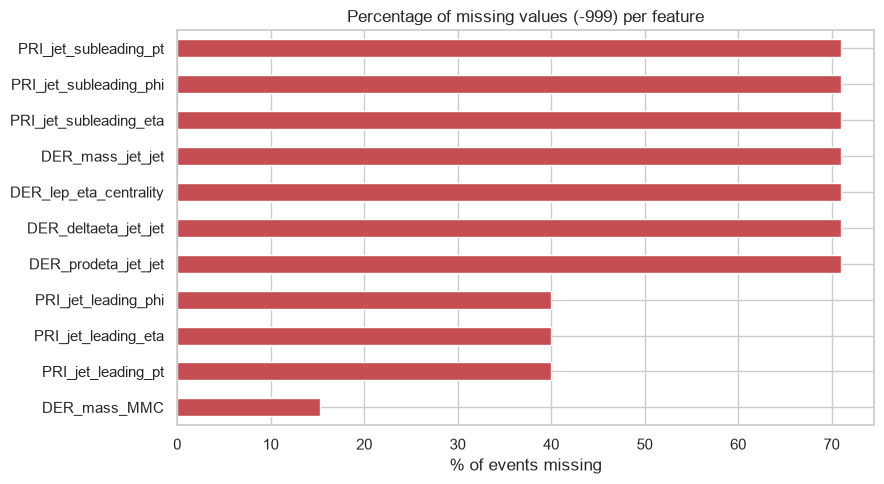

In [10]:
feature_cols = der_cols + pri_cols

print("Real NaN values in the data:", df[feature_cols].isna().sum().sum())

missing_pct = ((df[feature_cols] == -999).mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f"Columns with -999 values: {len(missing_pct)} of {len(feature_cols)}")
print(missing_pct.round(1).to_string())

rows_with_missing = (df[feature_cols] == -999).any(axis=1).mean() * 100
print(f"Rows with at least one -999: {rows_with_missing:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
missing_pct.sort_values().plot.barh(color="#C44E52", ax=ax)
ax.set_title("Percentage of missing values (-999) per feature")
ax.set_xlabel("% of events missing")
plt.tight_layout()
plt.show()

### 2.4 Why values are missing
- missing count grouped by `PRI_jet_num`
- jet features missing because there are no jets → structural, not random

Events per number of jets:
PRI_jet_num
0    99913
1    77544
2    50379
3    22164


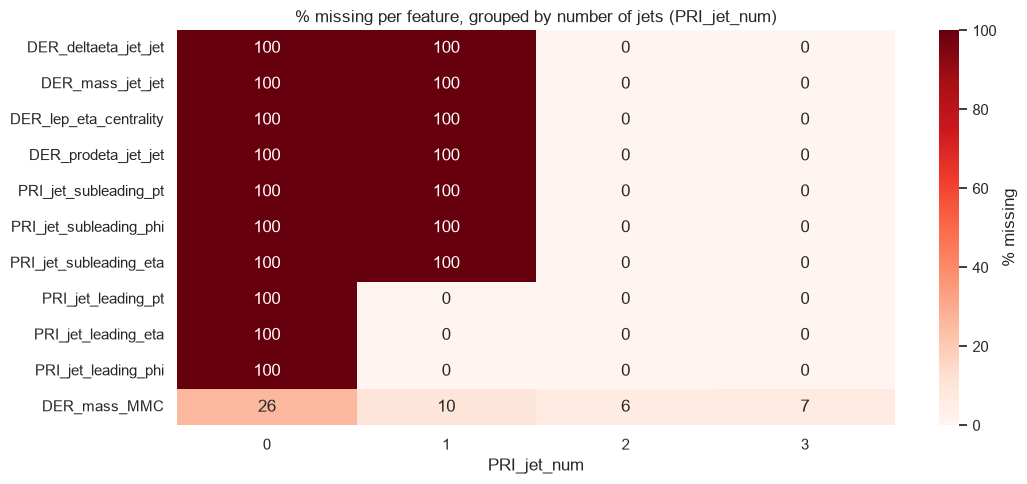

In [11]:
jet_counts = df["PRI_jet_num"].value_counts().sort_index()
print("Events per number of jets:")
print(jet_counts.to_string())

missing_by_jets = (df[missing_pct.index] == -999).groupby(df["PRI_jet_num"]).mean() * 100

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(missing_by_jets.T, annot=True, fmt=".0f", cmap="Reds", cbar_kws={"label": "% missing"}, ax=ax)
ax.set_title("% missing per feature, grouped by number of jets (PRI_jet_num)")
ax.set_xlabel("PRI_jet_num")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [12]:
mmc_missing = df["DER_mass_MMC"] == -999
signal_rate = df.groupby(mmc_missing)["Label"].apply(lambda s: (s == "s").mean() * 100)
signal_rate.index = ["DER_mass_MMC present", "DER_mass_MMC missing"]
print("% of signal events:")
print(signal_rate.round(1).to_string())

% of signal events:
DER_mass_MMC present    39.1
DER_mass_MMC missing     7.4


### 2.5 Feature distributions: signal vs background
- histograms of key features (DER_mass_MMC, DER_mass_transverse_met_lep, ...)

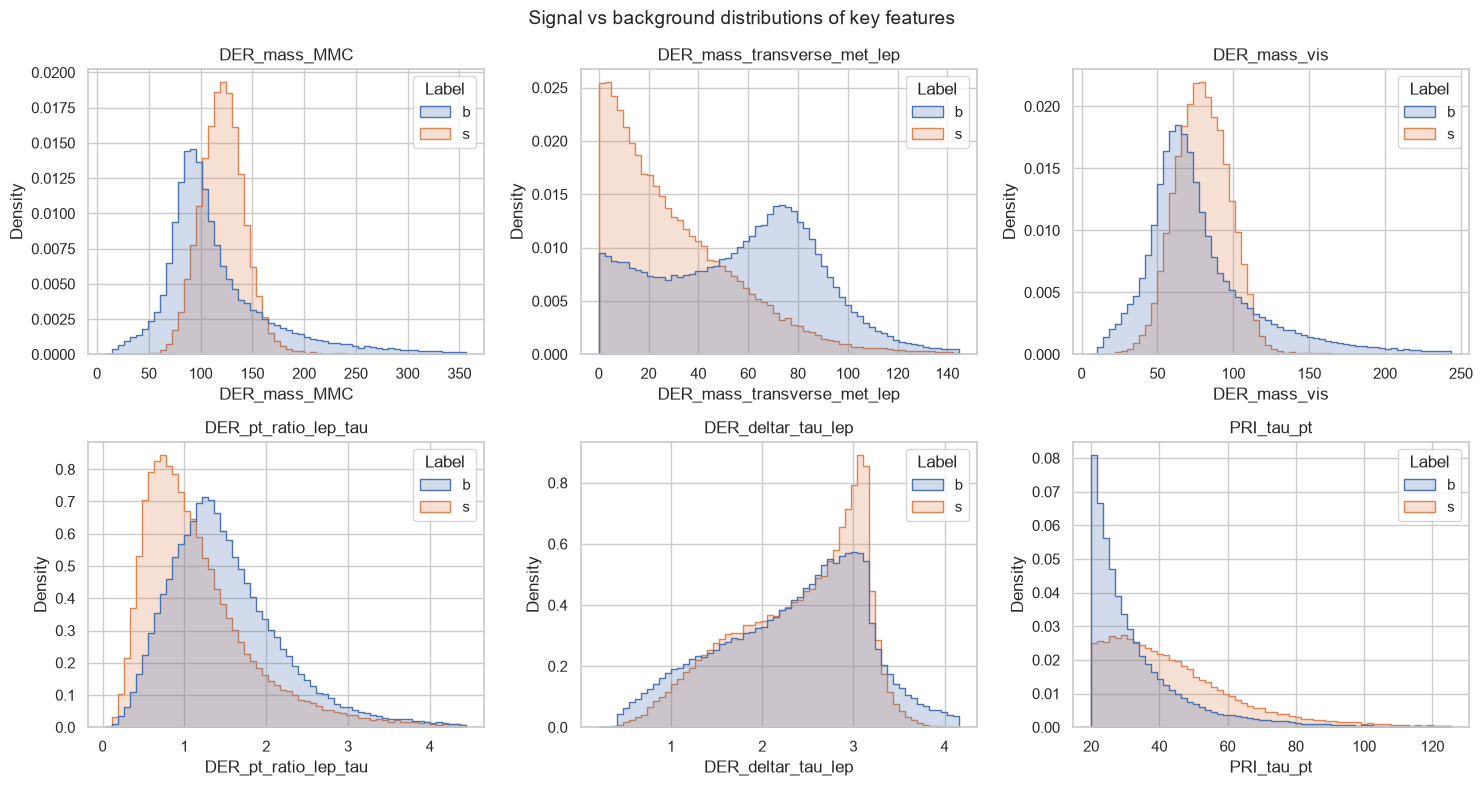

In [13]:
df_eda = df.replace(-999, np.nan)   # only for plotting; real preprocessing is in Part 3

key_features = ["DER_mass_MMC", "DER_mass_transverse_met_lep", "DER_mass_vis",
                "DER_pt_ratio_lep_tau", "DER_deltar_tau_lep", "PRI_tau_pt"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, key_features):
    upper = df_eda[col].quantile(0.99)          # cut the extreme 1% so the plot is readable
    data = df_eda[df_eda[col] <= upper]
    sns.histplot(data=data, x=col, hue="Label", hue_order=["b", "s"], bins=60,
                 stat="density", common_norm=False, element="step", palette=["#4C72B0", "#DD8452"], ax=ax)
    ax.set_title(col)
plt.suptitle("Signal vs background distributions of key features", fontsize=14)
plt.tight_layout()
plt.show()

### 2.6 Correlation analysis
- heatmap of the 30 features
- groups of highly correlated features

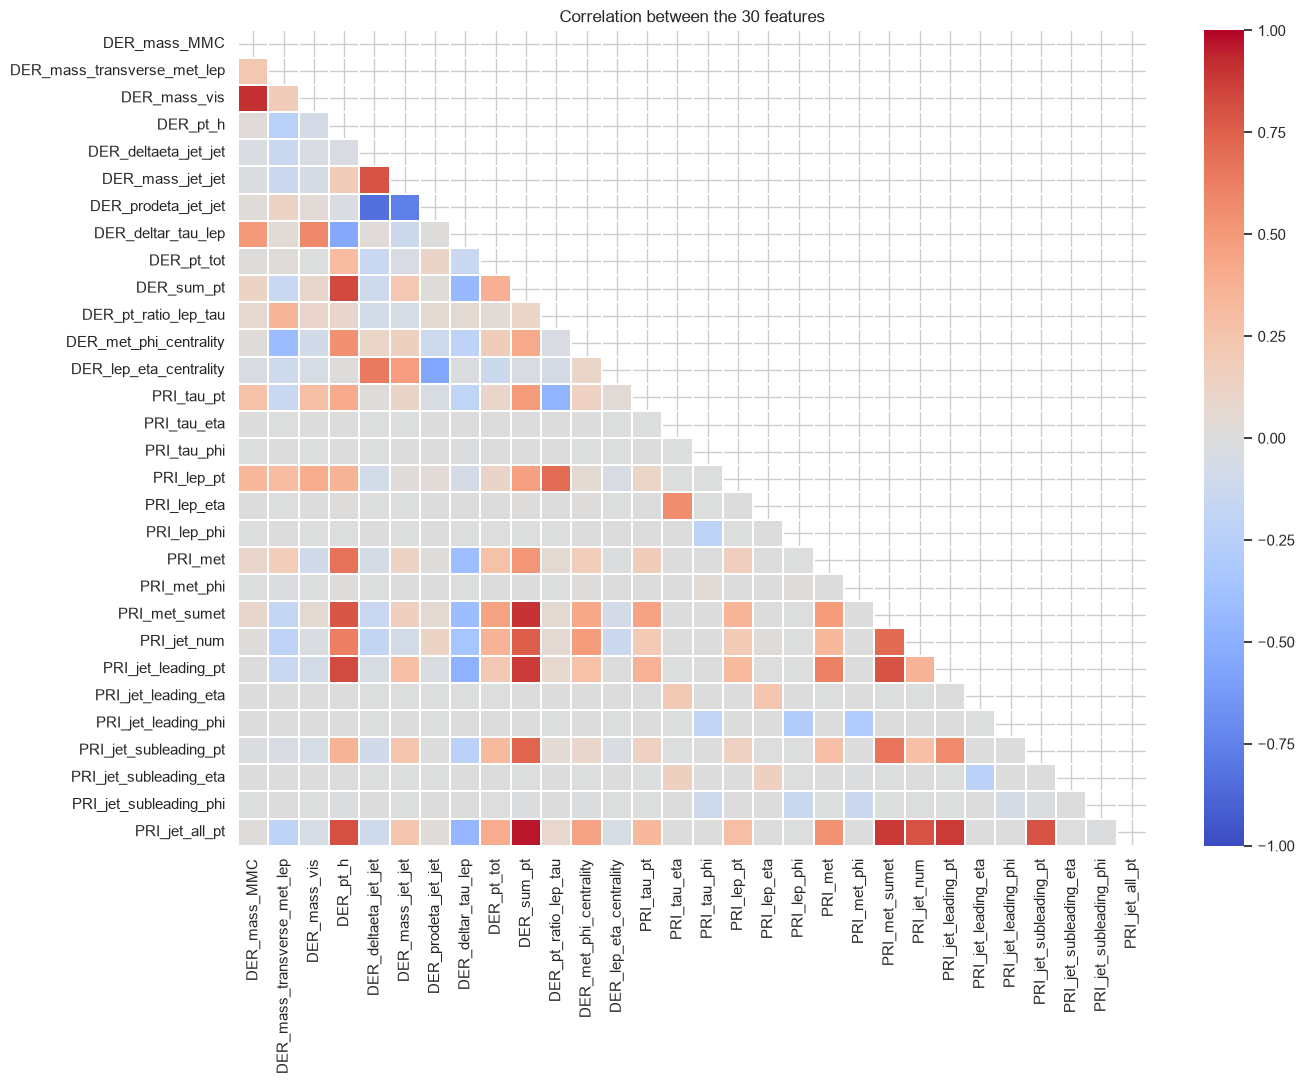

Strongly correlated pairs (|r| > 0.8):
DER_sum_pt            PRI_jet_all_pt         0.97
DER_mass_MMC          DER_mass_vis           0.91
DER_sum_pt            PRI_met_sumet          0.90
PRI_met_sumet         PRI_jet_all_pt         0.88
DER_sum_pt            PRI_jet_leading_pt     0.88
PRI_jet_leading_pt    PRI_jet_all_pt         0.88
DER_deltaeta_jet_jet  DER_prodeta_jet_jet   -0.84
DER_pt_h              DER_sum_pt             0.83
                      PRI_jet_leading_pt     0.83
                      PRI_jet_all_pt         0.81
PRI_jet_num           PRI_jet_all_pt         0.80


In [14]:
corr = df_eda[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax)
ax.set_title("Correlation between the 30 features")
plt.tight_layout()
plt.show()

pairs = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack()
strong = pairs[pairs.abs() > 0.8].sort_values(key=abs, ascending=False)
print("Strongly correlated pairs (|r| > 0.8):")
print(strong.round(2).to_string())

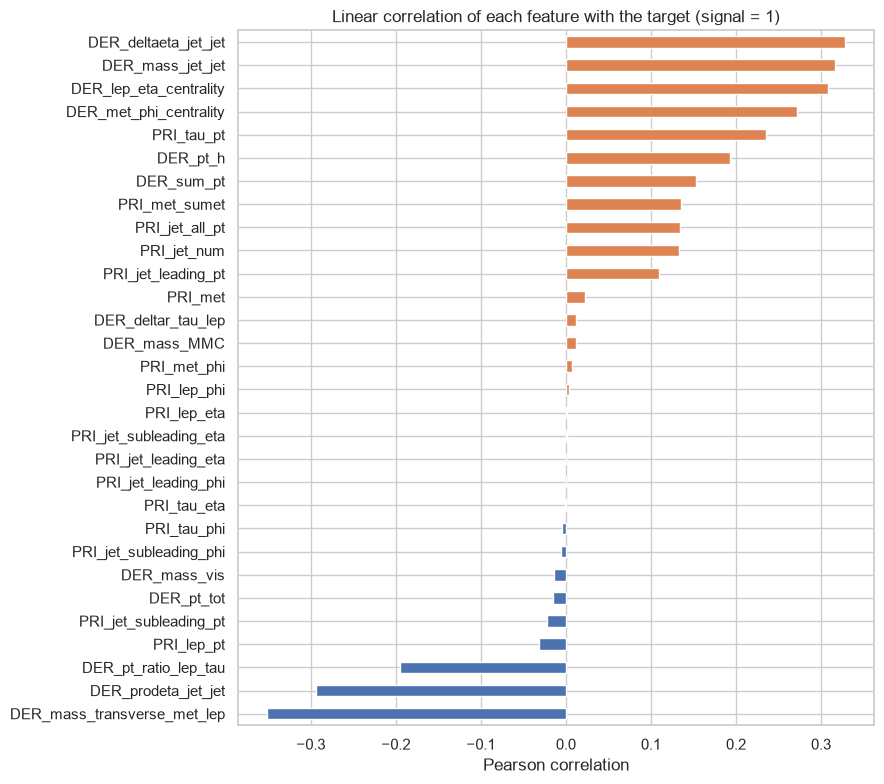

DER_mass_transverse_met_lep   -0.351
DER_deltaeta_jet_jet           0.328
DER_mass_jet_jet               0.317
DER_lep_eta_centrality         0.308
DER_prodeta_jet_jet           -0.294
DER_met_phi_centrality         0.272
PRI_tau_pt                     0.235
DER_pt_ratio_lep_tau          -0.195
DER_pt_h                       0.193
DER_sum_pt                     0.153


In [15]:
target = (df["Label"] == "s").astype(int)
corr_target = df_eda[feature_cols].corrwith(target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ordered = corr_target.sort_values()
ordered.plot.barh(color=np.where(ordered > 0, "#DD8452", "#4C72B0"), ax=ax)
ax.set_title("Linear correlation of each feature with the target (signal = 1)")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

print(corr_target.round(3).head(10).to_string())

### 2.7 EDA summary

| # | Finding | What it means for the model |
|---|---------|-----------------------------|
| 1 | 250,000 events, 30 features, all numeric | No encoding needed except the target (`s`/`b`) |
| 2 | Target: 65.7% background, 34.3% signal | Mild imbalance: no resampling, but judge with ROC-AUC, precision and recall, not accuracy alone |
| 3 | No real NaN, but 11 of 30 features use **-999** for missing; 72.8% of rows have at least one | Dropping rows would lose most of the data; -999 must become NaN (it even pushed the mean of `DER_mass_MMC` to -49) |
| 4 | Jet features are missing exactly when there are no jets (`PRI_jet_num` = 0 or 1) | Missingness is **structural**, not random: the value cannot exist |
| 5 | Signal rate is 39.1% when `DER_mass_MMC` exists but only 7.4% when it is missing | Missingness itself is useful information; mean imputation would erase it, while XGBoost learns a default direction for NaN |
| 6 | `DER_mass_MMC` clearly separates the classes (signal peaks near 125 GeV) yet its linear correlation with the target is only 0.01 | Relationships are **non-linear** (a bump, not a line): tree models can capture them, linear models cannot |
| 7 | No feature has a linear correlation above 0.35 with the target | Signal can only be found by combining many features, which is what boosting does |
| 8 | 11 feature pairs have \|r\| > 0.8 (e.g. `DER_sum_pt` and `PRI_jet_all_pt` = 0.97) | Correlated features do not hurt tree predictions, so all are kept, but they share importance (important when reading Part 7) |
| 9 | Features have very different scales and long tails | Trees split on thresholds, so **no scaling** is needed for XGBoost |

**Conclusion:** the Higgs data has exactly the properties XGBoost was designed for: lots of structured missing values, non-linear interactions, correlated features and unscaled numeric inputs. Part 3 therefore only converts -999 to NaN, encodes the target, drops leakage columns and splits the data, without imputation or scaling.

## 3. Data Preprocessing

### 3.1 Drop non-feature columns
- EventId, KaggleSet, KaggleWeight
- Weight → leaks the label

In [16]:
print("Weight by class (why it must be dropped):")
print(df.groupby("Label")["Weight"].describe().round(4))

Weight by class (why it must be dropped):
          count    mean     std     min     25%     50%     75%     max
Label                                                                  
b      164333.0  0.7626  0.5471  0.0195  0.4087  0.6343  1.3274  2.3852
s       85667.0  0.0025  0.0025  0.0005  0.0005  0.0005  0.0057  0.0057


In [17]:
drop_cols = ["EventId", "Weight", "KaggleSet", "KaggleWeight"]
data = df.drop(columns=drop_cols)
print(f"Dropped: {drop_cols}")
print(f"Remaining columns: {data.shape[1]} (30 features + Label)")

Dropped: ['EventId', 'Weight', 'KaggleSet', 'KaggleWeight']
Remaining columns: 31 (30 features + Label)


### 3.2 Encode the target
- s → 1, b → 0

In [18]:
y = (data["Label"] == "s").astype(int)   # signal = 1, background = 0
X = data.drop(columns="Label")

print(y.value_counts().rename({0: "b (0)", 1: "s (1)"}))
print(f"X shape: {X.shape}")

Label
b (0)    164333
s (1)     85667
Name: count, dtype: int64
X shape: (250000, 30)


### 3.3 Handle missing values
- -999 → NaN
- NO imputation: XGBoost learns a default direction for missing values

In [19]:
X = X.replace(-999, np.nan)

print(f"NaN values after conversion: {X.isna().sum().sum():,}")
print(f"Mean of DER_mass_MMC before: {df['DER_mass_MMC'].mean():.2f} -> after: {X['DER_mass_MMC'].mean():.2f}")

NaN values after conversion: 1,580,052
Mean of DER_mass_MMC before: -49.02 -> after: 121.86


### 3.4 Categorical feature
- `PRI_jet_num` kept as integer (ordinal 0–3)

In [20]:
print(X["PRI_jet_num"].dtype)
print(X["PRI_jet_num"].value_counts().sort_index())

int64
PRI_jet_num
0    99913
1    77544
2    50379
3    22164
Name: count, dtype: int64


### 3.5 Scaling
- not needed for trees (splits are thresholds)
- only the Logistic Regression baseline gets scaled (Part 8)

### 3.6 Train / validation / test split
- stratified 70 / 15 / 15
- validation → early stopping, test → final score only

In [21]:
# step 1: hold out 15% as the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

# step 2: split the remaining 85% into train (70% of all) and validation (15% of all)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, stratify=y_temp, random_state=RANDOM_STATE)

split_info = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "% of data": [len(X_train) / len(X) * 100, len(X_val) / len(X) * 100, len(X_test) / len(X) * 100],
    "% signal": [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100],
}, index=["train", "validation", "test"]).round(1)
split_info

,rows,% of data,% signal
train,175000,70.0,34.3
validation,37500,15.0,34.3
test,37500,15.0,34.3


### 3.7 Preprocessing summary

| Step | What we did | Why (for XGBoost) |
|------|-------------|-------------------|
| Drop columns | Removed `EventId`, `Weight`, `KaggleSet`, `KaggleWeight` | `EventId` is just a row number. `Weight` **leaks the label**: signal weights are 0.0005-0.006, background weights 0.02-2.4, so a model could cheat with it. The Kaggle columns are competition bookkeeping |
| Encode target | `s` → 1, `b` → 0 | XGBoost's `binary:logistic` objective needs a 0/1 target |
| Missing values | Replaced -999 with NaN (1,580,052 values), **no imputation** | XGBoost learns a default direction for NaN at every split. After the fix, the mean of `DER_mass_MMC` went from -49 to 121.9 |
| `PRI_jet_num` | Kept as an integer | It is a count (0-3), so its order is meaningful and a tree can split on it directly |
| Scaling | None | Trees split on thresholds ("is x < 94.8?"), so the scale of a feature does not change the result |
| Split | Stratified 70 / 15 / 15 → 175,000 / 37,500 / 37,500 rows | Stratification keeps 34.3% signal in every set. Validation is used for early stopping, the test set only for the final score |

## 4. Default XGBoost Model

### 4.1 Train with default parameters
- record training time

In [22]:
default_model = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1)

start = time.time()
default_model.fit(X_train, y_train)
default_time = time.time() - start
print(f"Training time: {default_time:.2f} s")

# read the real default values from the trained booster's configuration
config = json.loads(default_model.get_booster().save_config())
tree_params = config["learner"]["gradient_booster"]["tree_train_param"]
defaults = {"n_estimators": len(default_model.get_booster().get_dump())}
defaults.update({name: float(tree_params[key]) for name, key in [
    ("learning_rate", "eta"), ("max_depth", "max_depth"), ("min_child_weight", "min_child_weight"),
    ("gamma", "gamma"), ("subsample", "subsample"), ("colsample_bytree", "colsample_bytree"),
    ("reg_lambda", "lambda"), ("reg_alpha", "alpha")]})
pd.Series(defaults, name="default value").round(3)

Training time: 0.65 s


n_estimators        100.0
learning_rate         0.3
max_depth             6.0
min_child_weight      1.0
gamma                 0.0
subsample             1.0
colsample_bytree      1.0
reg_lambda            1.0
reg_alpha             0.0
Name: default value, dtype: float64

### 4.2 Evaluate the default model
- accuracy, precision, recall, F1, ROC-AUC

In [23]:
def evaluate(model, X_eval, y_eval, name):
    """Return the main classification metrics for one model on one dataset."""
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred),
        "recall": recall_score(y_eval, pred),
        "f1": f1_score(y_eval, pred),
        "roc_auc": roc_auc_score(y_eval, proba),
    }

default_scores = pd.DataFrame([
    evaluate(default_model, X_train, y_train, "default - train"),
    evaluate(default_model, X_test, y_test, "default - test"),
]).set_index("model").round(4)
default_scores

,accuracy,precision,recall,f1,roc_auc
model,,,,,
default - train,0.8652,0.8263,0.7683,0.7962,0.9355
default - test,0.8388,0.7872,0.7258,0.7553,0.9063


## 5. Hyperparameter Tuning

### 5.1 Search space and why
- learning_rate, max_depth, min_child_weight, gamma
- subsample, colsample_bytree, reg_lambda, reg_alpha

In [24]:
param_dist = {
    "n_estimators":     randint(200, 600),     # number of trees
    "learning_rate":    loguniform(0.02, 0.3), # shrinkage per tree
    "max_depth":        randint(3, 10),        # tree complexity
    "min_child_weight": randint(1, 10),        # min sum of hessians in a leaf
    "gamma":            uniform(0, 5),         # min gain needed to split
    "subsample":        uniform(0.6, 0.4),     # 60%-100% of rows per tree
    "colsample_bytree": uniform(0.5, 0.5),     # 50%-100% of columns per tree
    "reg_lambda":       loguniform(0.1, 10),   # L2 regularization
    "reg_alpha":        loguniform(1e-3, 1),   # L1 regularization
}

search_space = pd.DataFrame({
    "range": ["200 - 600", "0.02 - 0.3 (log)", "3 - 9", "1 - 9", "0 - 5", "0.6 - 1.0", "0.5 - 1.0", "0.1 - 10 (log)", "0.001 - 1 (log)"],
    "controls": ["number of trees", "step size of each tree", "depth / complexity of each tree", "minimum hessian sum in a leaf",
                 "minimum gain to make a split", "fraction of rows per tree", "fraction of columns per tree",
                 "L2 penalty on leaf weights", "L1 penalty on leaf weights"],
}, index=list(param_dist.keys()))
search_space

,range,controls
n_estimators,200 - 600,number of trees
learning_rate,0.02 - 0.3 (log),step size of each tree
max_depth,3 - 9,depth / complexity of each tree
min_child_weight,1 - 9,minimum hessian sum in a leaf
gamma,0 - 5,minimum gain to make a split
subsample,0.6 - 1.0,fraction of rows per tree
colsample_bytree,0.5 - 1.0,fraction of columns per tree
reg_lambda,0.1 - 10 (log),L2 penalty on leaf weights
reg_alpha,0.001 - 1 (log),L1 penalty on leaf weights


### 5.2 RandomizedSearchCV
- on a 50k-row sample (speed), 3-fold stratified CV, scoring = ROC-AUC

In [25]:
# tune on a stratified 50k sample of the training set to keep the search fast
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=50_000, stratify=y_train, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    verbose=1,
)

start = time.time()
search.fit(X_tune, y_tune)
print(f"Search time: {(time.time() - start) / 60:.1f} min")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Search time: 0.6 min
Best CV ROC-AUC: 0.9048


### 5.3 Best parameters

In [26]:
best_params = search.best_params_
print(pd.Series(best_params).round(4).to_string())

colsample_bytree      0.8038
gamma                 0.8526
learning_rate         0.0239
max_depth             6.0000
min_child_weight      9.0000
n_estimators        515.0000
reg_alpha             0.0490
reg_lambda            0.5900
subsample             0.6064


In [27]:
cv_results = pd.DataFrame(search.cv_results_)
top5 = cv_results.sort_values("rank_test_score").head(5)
cols = ["mean_test_score", "std_test_score"] + [c for c in cv_results.columns if c.startswith("param_")]
top5[cols].round(4)

,mean_test_score,std_test_score,param_colsample_bytree,param_gamma,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,param_reg_alpha,param_reg_lambda,param_subsample
4,0.9048,0.0012,0.8038,0.8526,0.0239,6,9,515,0.0490,0.5900,0.6064
22,0.9045,0.0008,0.6934,4.6836,0.0290,6,9,350,0.0421,2.4636,0.6914
18,0.9043,0.0007,0.6334,4.8831,0.0609,9,5,423,0.5306,0.3014,0.6580
24,0.9041,0.0011,0.8166,1.6951,0.0515,5,4,351,0.0164,5.9640,0.9404
20,0.9040,0.0008,0.7352,4.9171,0.0589,9,1,400,0.0092,0.2361,0.6163


### 5.4 Final model with early stopping
- retrain on the full training set
- low learning rate + many trees, stop on validation logloss

In [28]:
final_params = {**best_params, "learning_rate": 0.05, "n_estimators": 3000}

final_model = XGBClassifier(
    **final_params,
    early_stopping_rounds=100,      # stop when validation logloss hasn't improved for 100 trees
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

start = time.time()
final_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
final_time = time.time() - start

print(f"Training time: {final_time:.1f} s")
print(f"Best iteration: {final_model.best_iteration} trees (out of max 3000)")
print(f"Best validation logloss: {final_model.best_score:.4f}")

Training time: 5.3 s
Best iteration: 777 trees (out of max 3000)
Best validation logloss: 0.3450


### 5.5 Learning curve
- train vs validation logloss per boosting round

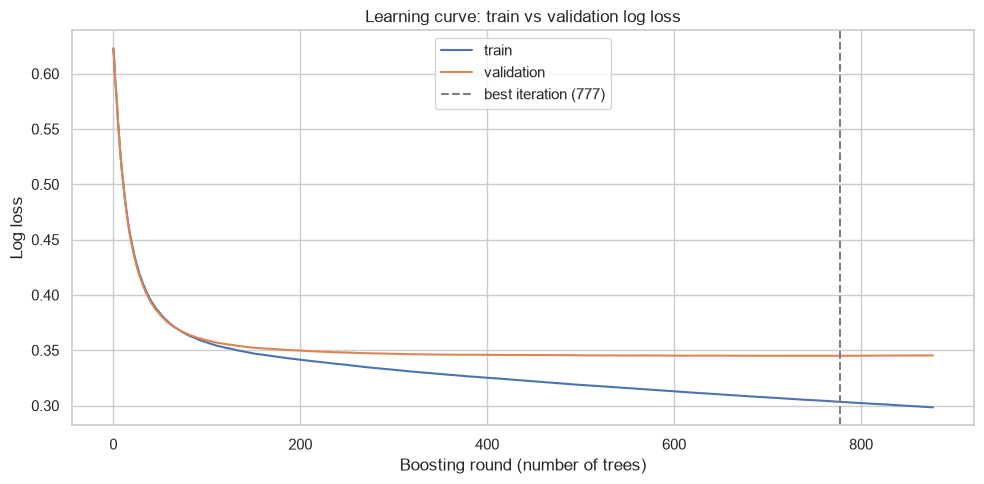

In [29]:
history = final_model.evals_result()
train_loss = history["validation_0"]["logloss"]
val_loss = history["validation_1"]["logloss"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_loss, label="train")
ax.plot(val_loss, label="validation")
ax.axvline(final_model.best_iteration, color="gray", linestyle="--", label=f"best iteration ({final_model.best_iteration})")
ax.set_xlabel("Boosting round (number of trees)")
ax.set_ylabel("Log loss")
ax.set_title("Learning curve: train vs validation log loss")
ax.legend()
plt.tight_layout()
plt.show()

### 5.6 How each hyperparameter affects the model
- change **one** parameter at a time and keep the others fixed (300 trees, learning rate 0.1, depth 6)
- compare **train** vs **validation** ROC-AUC: when the two lines separate, the model starts to overfit
- for `min_child_weight` and `gamma` the trees are made deep (depth 10) so that their regularizing effect is visible

In [30]:
base_hp = dict(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
sweeps = {
    "max_depth":        [2, 3, 4, 6, 8, 10, 12],
    "learning_rate":    [0.01, 0.03, 0.1, 0.3, 0.6, 1.0],
    "min_child_weight": [1, 5, 20, 50, 100, 300],
    "gamma":            [0, 1, 5, 10, 20, 50],
    "subsample":        [0.3, 0.5, 0.7, 0.9, 1.0],
}

start = time.time()
sweep_rows = []
for param, values in sweeps.items():
    for value in values:
        settings = {**base_hp, param: value}
        if param in ("min_child_weight", "gamma"):
            settings["max_depth"] = 10
        model = XGBClassifier(**settings).fit(X_train, y_train)
        sweep_rows.append({"param": param, "value": value,
                           "train": roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
                           "validation": roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])})
sweep_df = pd.DataFrame(sweep_rows)

# n_estimators: one long model, read the score after every tree
curve_model = XGBClassifier(n_estimators=1500, learning_rate=0.1, max_depth=6, eval_metric="auc",
                            random_state=RANDOM_STATE, n_jobs=-1)
curve_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
auc_history = curve_model.evals_result()
print(f"Done in {time.time() - start:.0f} s")

Done in 97 s


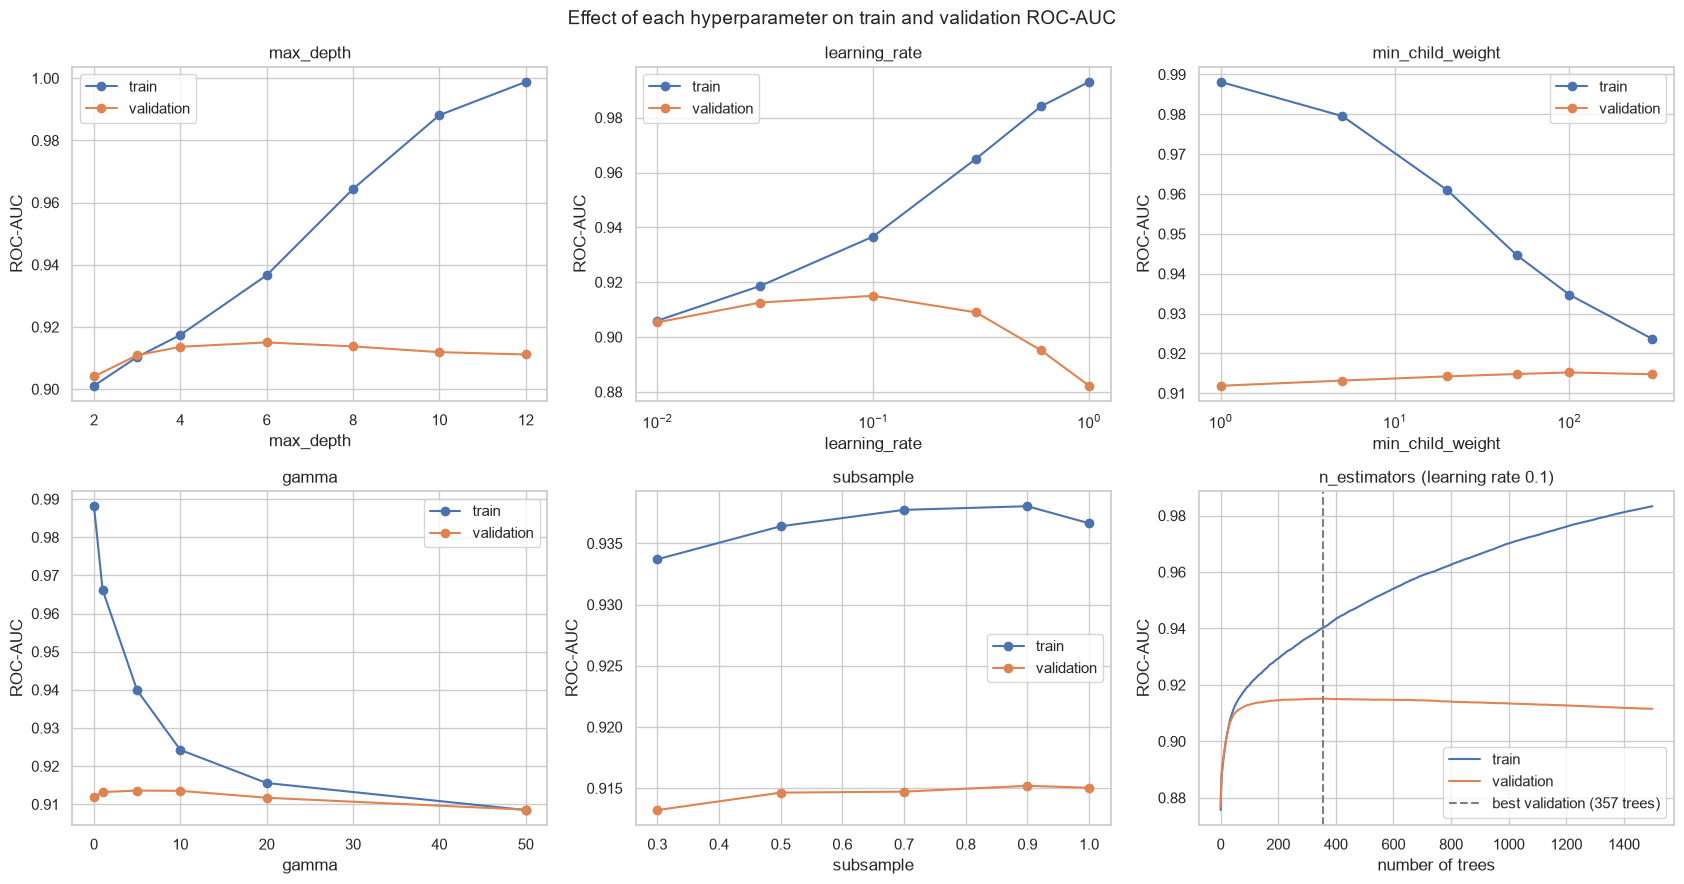

train  validation
param            value                     
gamma            0.00    0.9881      0.9119
                 1.00    0.9662      0.9132
                 5.00    0.9399      0.9136
                 10.00   0.9243      0.9135
                 20.00   0.9156      0.9117
                 50.00   0.9085      0.9086
learning_rate    0.01    0.9060      0.9053
                 0.03    0.9186      0.9126
                 0.10    0.9366      0.9150
                 0.30    0.9651      0.9090
                 0.60    0.9842      0.8951
                 1.00    0.9930      0.8822
max_depth        2.00    0.9011      0.9041
                 3.00    0.9103      0.9109
                 4.00    0.9174      0.9136
                 6.00    0.9366      0.9150
                 8.00    0.9644      0.9137
                 10.00   0.9881      0.9119
                 12.00   0.9988      0.9111
min_child_weight 1.00    0.9881      0.9119
                 5.00    0.9795      0.9132
                 20.00   0.9609      0.9143
                 50.00   0.9447      0.9148
                 100.00  0.9348      0.9152
                 300.00  0.9236      0.9148
subsample        0.30    0.9337      0.9132
                 0.50    0.9364      0.9146
                 0.70    0.9377      0.9147
                 0.90    0.9380      0.9152
                 1.00    0.9366      0.9150

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, param in zip(axes.flat, sweeps):
    part = sweep_df[sweep_df["param"] == param]
    ax.plot(part["value"], part["train"], "o-", label="train")
    ax.plot(part["value"], part["validation"], "o-", label="validation")
    if param in ("learning_rate", "min_child_weight"):
        ax.set_xscale("log")
    ax.set_title(param)
    ax.set_xlabel(param)
    ax.set_ylabel("ROC-AUC")
    ax.legend()

ax = axes.flat[5]
ax.plot(auc_history["validation_0"]["auc"], label="train")
ax.plot(auc_history["validation_1"]["auc"], label="validation")
best_round = int(np.argmax(auc_history["validation_1"]["auc"]))
ax.axvline(best_round, color="gray", linestyle="--", label=f"best validation ({best_round} trees)")
ax.set_title("n_estimators (learning rate 0.1)")
ax.set_xlabel("number of trees")
ax.set_ylabel("ROC-AUC")
ax.legend()
plt.suptitle("Effect of each hyperparameter on train and validation ROC-AUC", fontsize=14)
plt.tight_layout()
plt.show()

sweep_df.pivot_table(index=["param", "value"], values=["train", "validation"]).round(4)

**What the hyperparameter plots show**

- **max_depth:** shallow trees (2-3) underfit, with train and validation equally low. From depth 8 the train score keeps rising (0.999 at depth 12) while validation falls. The best validation score is around **depth 6**.
- **learning_rate:** with a fixed 300 trees, 0.01 is too slow (still underfitting) and 0.6-1.0 overfit badly (validation drops to 0.882). **0.1 was best here.** A lower rate needs more trees.
- **n_estimators:** validation AUC rises quickly and then flattens, while train keeps climbing. That is exactly why we use early stopping.
- **min_child_weight** and **gamma** are brakes. On deep trees, raising them pulls the train score down towards validation and slightly *improves* validation (min_child_weight 100: 0.915), until too much braking starts to underfit (gamma 50).
- **subsample:** using 70-90% of the rows per tree is as good as or slightly better than 100%, because the randomness acts as regularization.
- **Practical recommendation:** depth 4-8, learning rate 0.05-0.1 with early stopping, min_child_weight and gamma > 0 for deep trees, and subsample/colsample around 0.8.

## 6. Model Evaluation (Tuned Model)

### 6.1 Classification report

In [32]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["background (0)", "signal (1)"], digits=4))

                precision    recall  f1-score   support

background (0)     0.8660    0.9007    0.8830     24650
    signal (1)     0.7937    0.7328    0.7620     12850

      accuracy                         0.8431     37500
     macro avg     0.8299    0.8167    0.8225     37500
  weighted avg     0.8412    0.8431    0.8416     37500



### 6.2 Confusion matrix

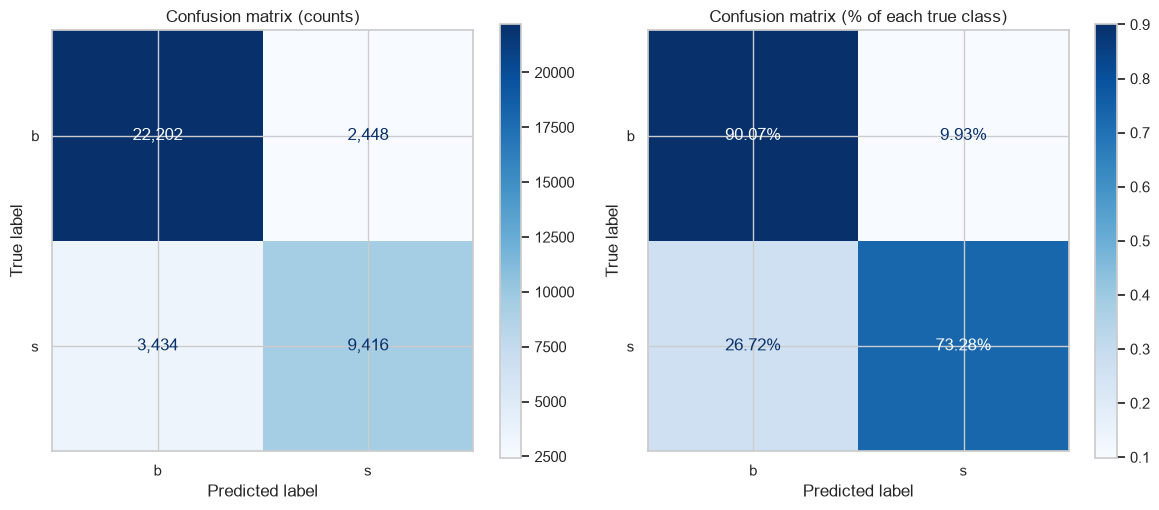

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["b", "s"], cmap="Blues", values_format=",", ax=axes[0])
axes[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["b", "s"], cmap="Blues", normalize="true", values_format=".2%", ax=axes[1])
axes[1].set_title("Confusion matrix (% of each true class)")
plt.tight_layout()
plt.show()

### 6.3 ROC curve and Precision-Recall curve

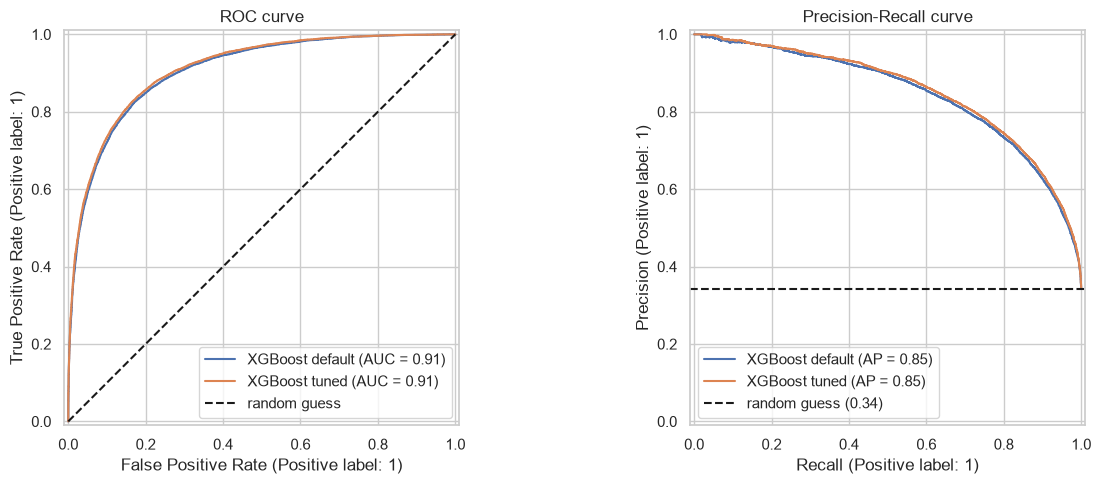

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_estimator(default_model, X_test, y_test, name="XGBoost default", ax=axes[0])
RocCurveDisplay.from_estimator(final_model, X_test, y_test, name="XGBoost tuned", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="random guess")
axes[0].set_title("ROC curve")
axes[0].legend()

PrecisionRecallDisplay.from_estimator(default_model, X_test, y_test, name="XGBoost default", ax=axes[1])
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, name="XGBoost tuned", ax=axes[1])
axes[1].axhline(y_test.mean(), color="k", linestyle="--", label=f"random guess ({y_test.mean():.2f})")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
plt.tight_layout()
plt.show()

### 6.4 Default vs tuned comparison table

In [35]:
comparison = pd.DataFrame([
    evaluate(default_model, X_test, y_test, "XGBoost default"),
    evaluate(final_model, X_test, y_test, "XGBoost tuned"),
]).set_index("model")
comparison["n_trees"] = [default_model.n_estimators or 100, final_model.best_iteration + 1]
comparison["train_time_s"] = [default_time, final_time]
comparison.round(4)

,accuracy,precision,recall,f1,roc_auc,n_trees,train_time_s
model,,,,,,,
XGBoost default,0.8388,0.7872,0.7258,0.7553,0.9063,100,0.6490
XGBoost tuned,0.8431,0.7937,0.7328,0.7620,0.9108,778,5.3271


In [36]:
train_auc = roc_auc_score(y_train, final_model.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, y_proba)
print(f"Tuned model ROC-AUC  train: {train_auc:.4f} | test: {test_auc:.4f} | gap: {train_auc - test_auc:.4f}")

Tuned model ROC-AUC  train: 0.9374 | test: 0.9108 | gap: 0.0266


### 6.5 Interpretation of results

- The tuned model reaches a **test ROC-AUC of 0.9108** (default: 0.9063), with **84.3% accuracy** and an F1 of 0.762 for the signal class.
- **Background** events are recognised well (recall 90.1%). **Signal** recall is 73.3%, so about 1 in 4 Higgs events is missed. Some signal and background events look the same physically, so a perfect score is not possible.
- **Precision for signal is 79.4%**: when the model says "Higgs", it is right about 4 times out of 5.
- If finding more signal mattered more than false alarms, we could lower the 0.5 threshold (precision-recall trade-off) or use `scale_pos_weight`.
- **Tuning helped only a little (+0.0045 AUC)**: XGBoost's defaults are already strong. The best settings mainly add regularization (`min_child_weight` 9, `subsample` 0.61, `gamma` 0.85) and smaller steps.
- **Learning curve:** the validation loss flattens after about 300 trees while the training loss keeps falling, which means the extra trees start memorising the training data. Early stopping picked 778 trees, the point where validation loss was lowest.
- **Train vs test ROC-AUC gap is 0.027**: mild overfitting that is under control.

### 6.6 Overfitting check
- compare ROC-AUC on train / validation / test: a big train-test gap means the model memorised the training data
- train two models **on purpose without protection** (no early stopping, deep trees with no regularization) to see what overfitting looks like
- 5-fold cross-validation: is the score stable across different splits?

In [37]:
def auc_by_split(model):
    return {name: roc_auc_score(y_true, model.predict_proba(X_part)[:, 1])
            for name, X_part, y_true in [("train", X_train, y_train), ("validation", X_val, y_val), ("test", X_test, y_test)]}

# two models that are allowed to overfit
no_stop_model = XGBClassifier(**final_params, random_state=RANDOM_STATE, n_jobs=-1)          # 3000 trees, no early stopping
no_stop_model.fit(X_train, y_train)
deep_model = XGBClassifier(max_depth=12, min_child_weight=1, n_estimators=500, learning_rate=0.1,
                           random_state=RANDOM_STATE, n_jobs=-1)                               # very deep trees, no regularization
deep_model.fit(X_train, y_train)

overfit_df = pd.DataFrame({
    "XGBoost default": auc_by_split(default_model),
    "XGBoost tuned + early stopping": auc_by_split(final_model),
    "tuned, 3000 trees, NO early stopping": auc_by_split(no_stop_model),
    "deep trees, NO regularization": auc_by_split(deep_model),
}).T
overfit_df["gap (train - test)"] = overfit_df["train"] - overfit_df["test"]
overfit_df.round(4)

,train,validation,test,gap (train - test)
XGBoost default,0.9355,0.9121,0.9063,0.0292
XGBoost tuned + early stopping,0.9374,0.9158,0.9108,0.0266
"tuned, 3000 trees, NO early stopping",0.9756,0.9123,0.9072,0.0684
"deep trees, NO regularization",1.0000,0.9103,0.9048,0.0952


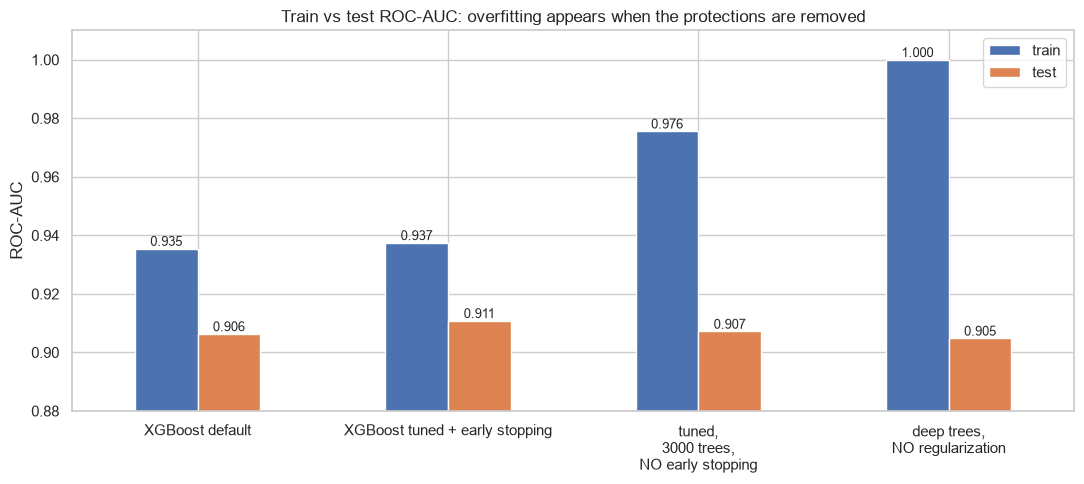

In [38]:
ax = overfit_df[["train", "test"]].plot.bar(figsize=(11, 5), color=["#4C72B0", "#DD8452"], rot=0)
ax.set_ylim(0.88, 1.01)
ax.set_ylabel("ROC-AUC")
ax.set_title("Train vs test ROC-AUC: overfitting appears when the protections are removed")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9)
ax.set_xticklabels([label.get_text().replace(", ", ",\n") for label in ax.get_xticklabels()])
plt.tight_layout()
plt.show()

In [39]:
cv_model = XGBClassifier(**{**final_params, "n_estimators": final_model.best_iteration + 1},
                         random_state=RANDOM_STATE, n_jobs=-1)
cv_scores = cross_val_score(cv_model, X_train, y_train, scoring="roc_auc",
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
print("ROC-AUC per fold:", cv_scores.round(4))
print(f"Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

ROC-AUC per fold: [0.9114 0.9109 0.9106 0.9117 0.9067]
Mean: 0.9102 +/- 0.0018


**What the overfitting check shows**

- The tuned model with early stopping has a **small train-test gap (about 0.02-0.03)** and the **best test score**.
- Without early stopping (3000 trees), the train score jumps to about 0.98 while the test score drops: the extra trees only memorise the training data.
- Very deep trees with no regularization reach a **perfect train score (1.000)** but the **worst test score**: classic overfitting.
- The 5-fold cross-validation scores are all close together (spread of about ±0.002), so the test score is not the result of a lucky split.
- **Conclusion:** XGBoost can overfit badly, but regularization (`min_child_weight`, `gamma`, `subsample`, `reg_lambda`) and early stopping keep it under control.

### 6.7 Choosing the decision threshold (and the AMS metric)
- by default an event is called signal when P(signal) ≥ 0.5, but that is just a convention
- precision, recall and F1 for every threshold; the threshold is chosen on the **validation** set and then checked on the test set
- **AMS (Approximate Median Significance)** was the official score of the 2014 Higgs challenge. It uses the event weights and rewards finding signal while keeping background very low

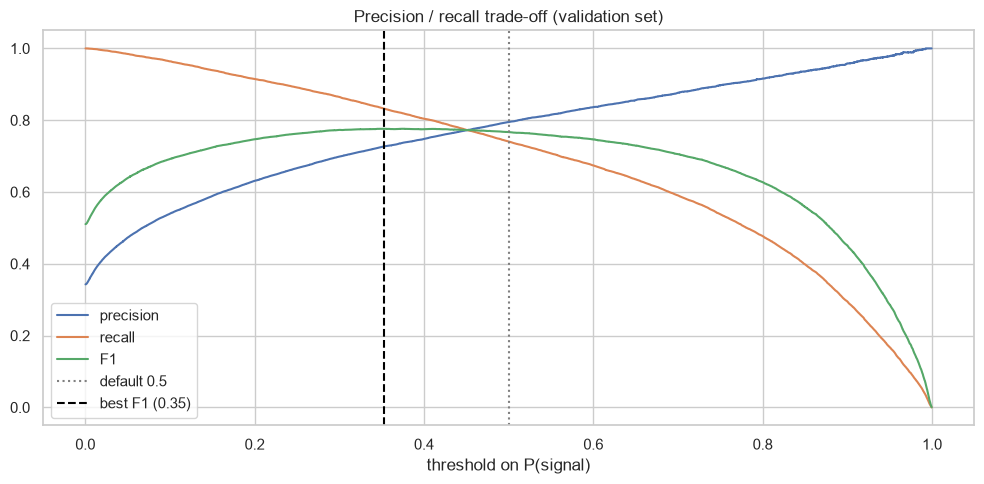

,threshold,precision,recall,f1
default 0.5,0.5000,0.7937,0.7328,0.7620
best F1 (from validation),0.3523,0.7222,0.8261,0.7706


In [40]:
val_proba = final_model.predict_proba(X_val)[:, 1]
precision_v, recall_v, thresholds_v = precision_recall_curve(y_val, val_proba)
f1_v = 2 * precision_v * recall_v / (precision_v + recall_v + 1e-12)
best_f1_threshold = thresholds_v[np.argmax(f1_v[:-1])]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_v, precision_v[:-1], label="precision")
ax.plot(thresholds_v, recall_v[:-1], label="recall")
ax.plot(thresholds_v, f1_v[:-1], label="F1")
ax.axvline(0.5, color="gray", linestyle=":", label="default 0.5")
ax.axvline(best_f1_threshold, color="black", linestyle="--", label=f"best F1 ({best_f1_threshold:.2f})")
ax.set_xlabel("threshold on P(signal)")
ax.set_title("Precision / recall trade-off (validation set)")
ax.legend()
plt.tight_layout()
plt.show()

threshold_table = pd.DataFrame([
    {"threshold": t,
     "precision": precision_score(y_test, y_proba >= t),
     "recall": recall_score(y_test, y_proba >= t),
     "f1": f1_score(y_test, y_proba >= t)}
    for t in [0.5, best_f1_threshold]], index=["default 0.5", "best F1 (from validation)"])
threshold_table.round(4)

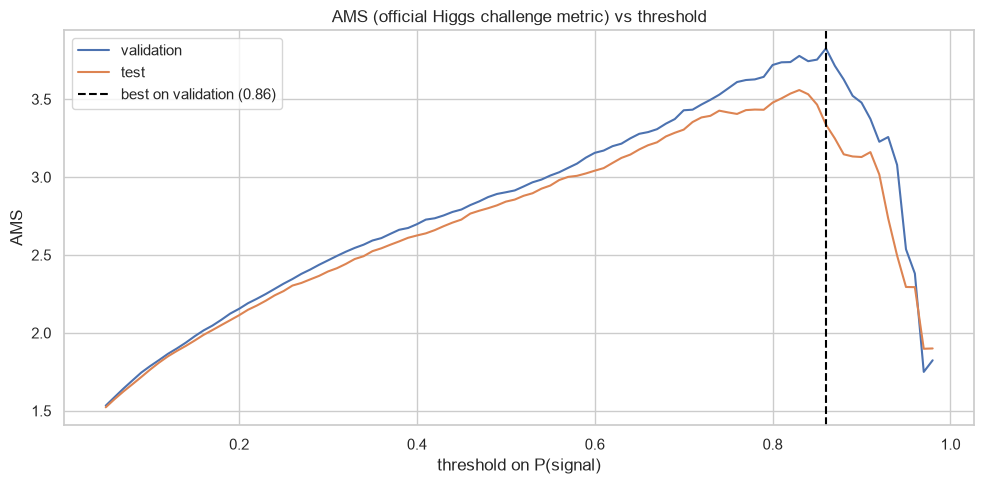

Test AMS at threshold 0.50: 2.842
Test AMS at threshold 0.86: 3.336
Events selected as signal at 0.86: 13.6%


In [41]:
def ams_score(s, b, b_reg=10.0):
    """Official metric of the Higgs challenge: s and b are the weighted signal and background selected."""
    return np.sqrt(2 * ((s + b + b_reg) * np.log(1 + s / (b + b_reg)) - s))

def ams_curve(X_part, y_part, grid):
    w = df.loc[X_part.index, "KaggleWeight"].to_numpy().copy()
    y_arr = y_part.to_numpy()
    # rescale the weights so this subset represents the full dataset (as in the competition)
    w[y_arr == 1] *= df.loc[df["Label"] == "s", "KaggleWeight"].sum() / w[y_arr == 1].sum()
    w[y_arr == 0] *= df.loc[df["Label"] == "b", "KaggleWeight"].sum() / w[y_arr == 0].sum()
    proba = final_model.predict_proba(X_part)[:, 1]
    return np.array([ams_score(w[(proba >= t) & (y_arr == 1)].sum(), w[(proba >= t) & (y_arr == 0)].sum()) for t in grid])

grid = np.linspace(0.05, 0.98, 94)
ams_val = ams_curve(X_val, y_val, grid)
ams_test = ams_curve(X_test, y_test, grid)
best_ams_threshold = grid[np.argmax(ams_val)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(grid, ams_val, label="validation")
ax.plot(grid, ams_test, label="test")
ax.axvline(best_ams_threshold, color="black", linestyle="--", label=f"best on validation ({best_ams_threshold:.2f})")
ax.set_xlabel("threshold on P(signal)")
ax.set_ylabel("AMS")
ax.set_title("AMS (official Higgs challenge metric) vs threshold")
ax.legend()
plt.tight_layout()
plt.show()

i_half = np.argmin(np.abs(grid - 0.5))
i_best = np.argmin(np.abs(grid - best_ams_threshold))
print(f"Test AMS at threshold 0.50: {ams_test[i_half]:.3f}")
print(f"Test AMS at threshold {best_ams_threshold:.2f}: {ams_test[i_best]:.3f}")
print(f"Events selected as signal at {best_ams_threshold:.2f}: {(y_proba >= best_ams_threshold).mean() * 100:.1f}%")

**What the threshold analysis shows**

- Lowering the threshold from 0.5 to **0.35** (chosen on the validation set) raises signal recall on the test set from **73.3% to 82.6%**. Precision drops from 79.4% to 72.2%, and F1 improves slightly (0.762 → 0.771).
- The physicists' goal was different: find a **very pure** set of signal events. The AMS metric therefore prefers a **high threshold (0.86)**, keeping only the 13.6% most signal-like events. Test AMS goes from **2.84** at 0.5 to **3.34**.
- For comparison, the 2014 competition winner scored about 3.8 AMS on the hidden leaderboard data. That is a different dataset, so the numbers are not directly comparable, but a single XGBoost model gets most of the way there.
- **Lesson:** the "best" threshold depends on the goal of the project, not on the model.

## 7. Feature Importance and Model Interpretation

### 7.1 Built-in importance: weight vs gain vs cover

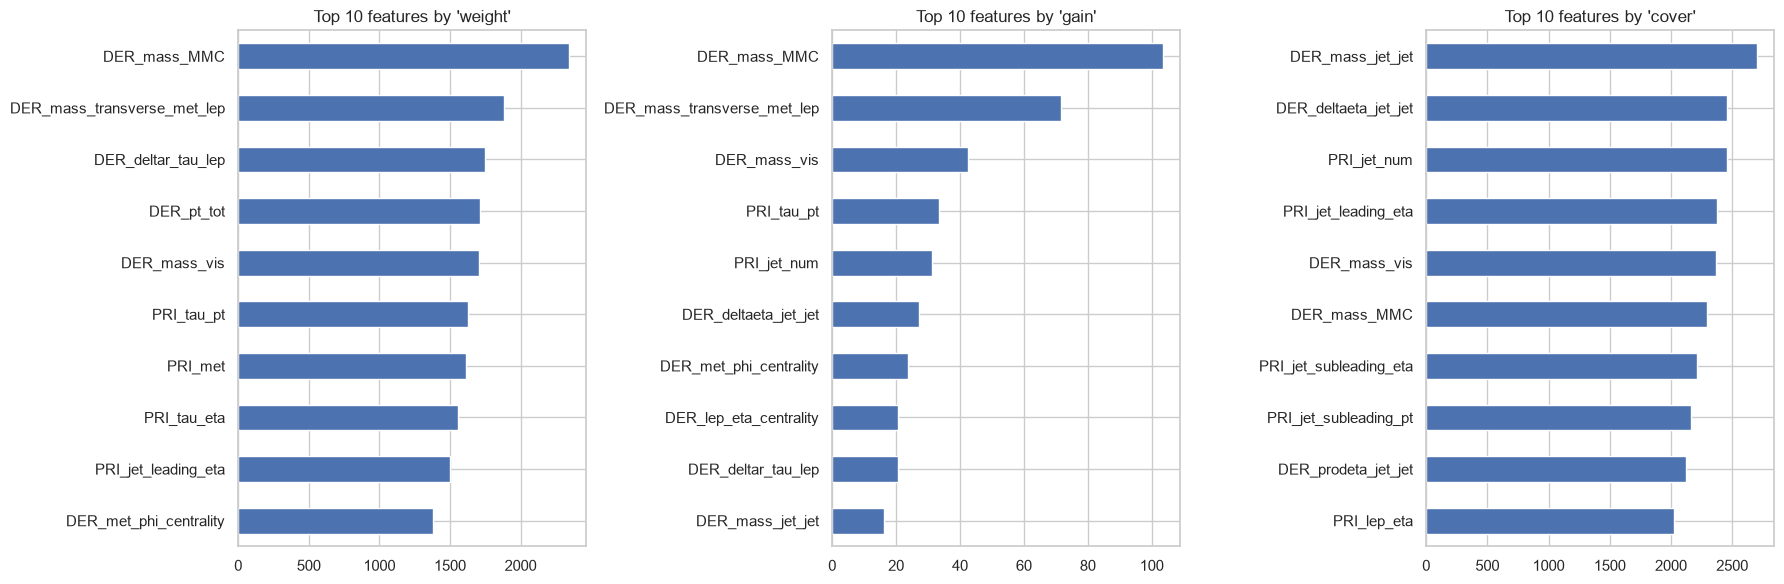

In [42]:
booster = final_model.get_booster()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp_type in zip(axes, ["weight", "gain", "cover"]):
    scores = pd.Series(booster.get_score(importance_type=imp_type)).sort_values().tail(10)
    scores.plot.barh(ax=ax, color="#4C72B0")
    ax.set_title(f"Top 10 features by '{imp_type}'")
plt.tight_layout()
plt.show()

### 7.2 SHAP summary plot

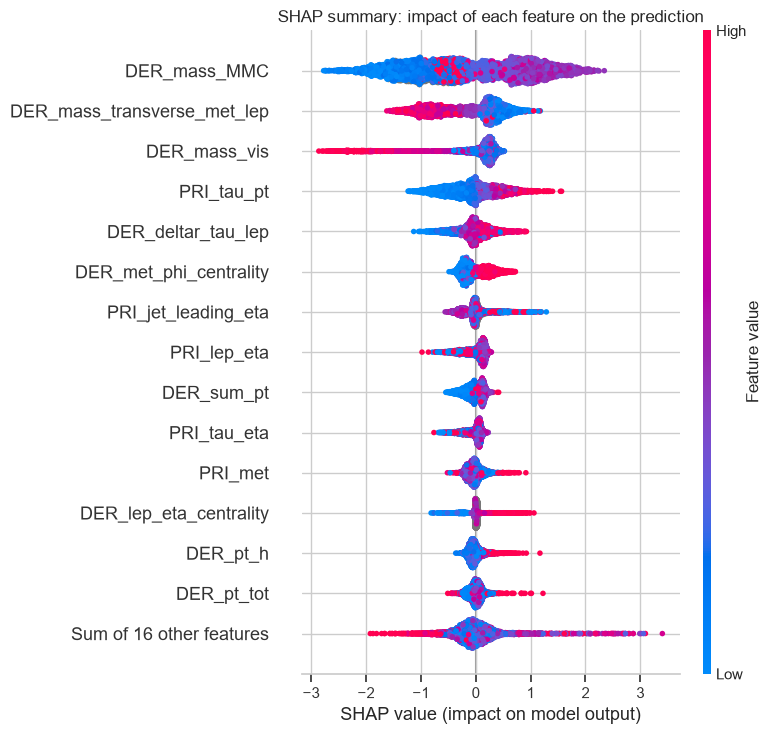

In [43]:
X_shap = X_test.sample(5000, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_shap)

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP summary: impact of each feature on the prediction")
plt.tight_layout()
plt.show()

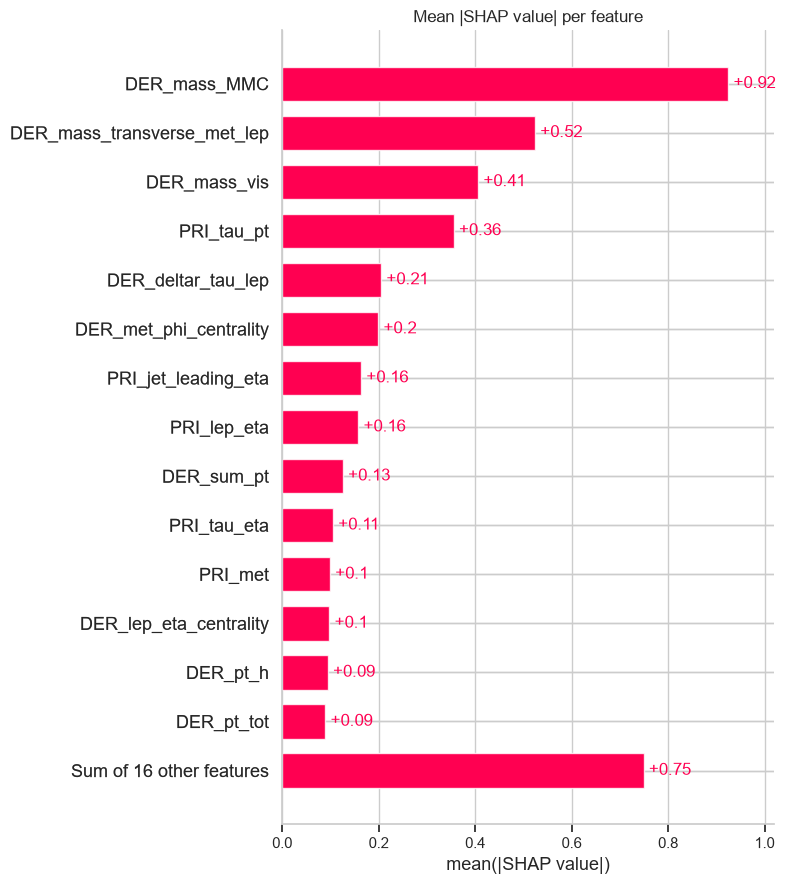

In [44]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Mean |SHAP value| per feature")
plt.tight_layout()
plt.show()

### 7.3 SHAP dependence plot (top feature)

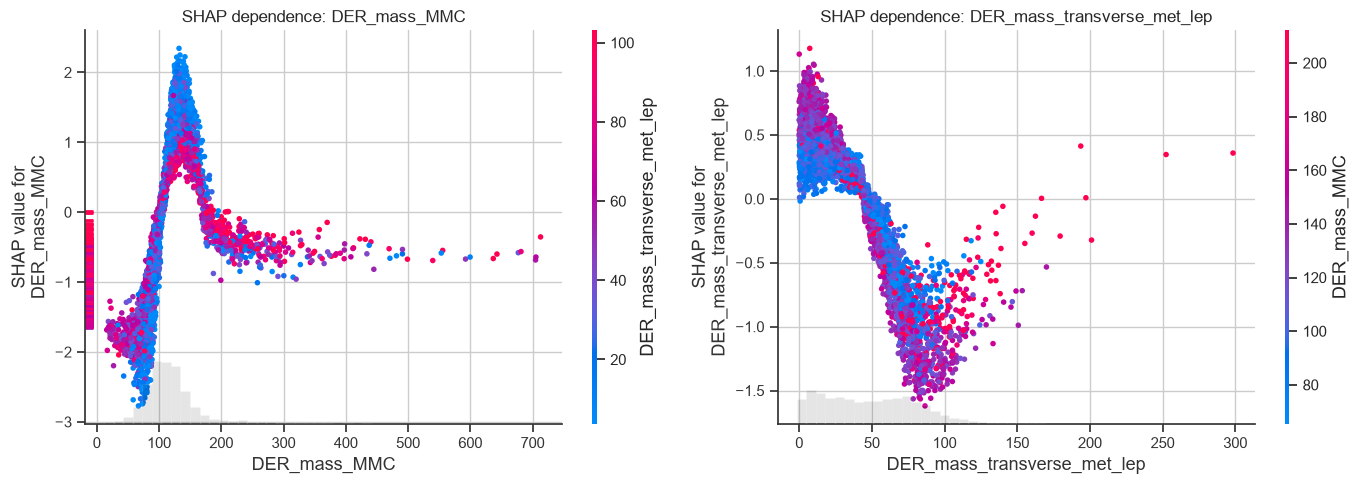

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shap.plots.scatter(shap_values[:, "DER_mass_MMC"], color=shap_values[:, "DER_mass_transverse_met_lep"], ax=axes[0], show=False)
axes[0].set_title("SHAP dependence: DER_mass_MMC")
shap.plots.scatter(shap_values[:, "DER_mass_transverse_met_lep"], color=shap_values[:, "DER_mass_MMC"], ax=axes[1], show=False)
axes[1].set_title("SHAP dependence: DER_mass_transverse_met_lep")
plt.tight_layout()
plt.show()

### 7.4 Partial dependence plot (optional)

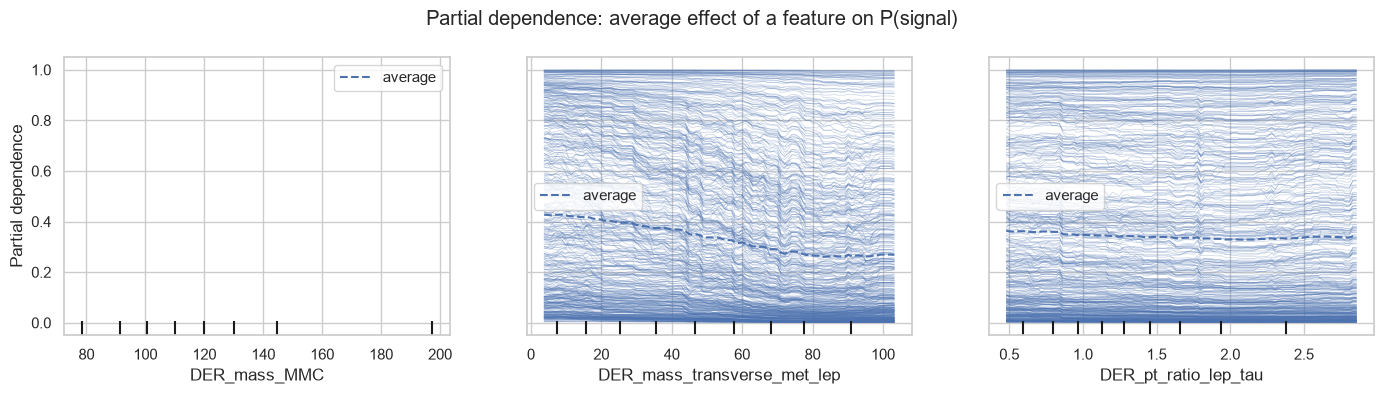

In [46]:
fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    final_model, X_shap, features=["DER_mass_MMC", "DER_mass_transverse_met_lep", "DER_pt_ratio_lep_tau"],
    kind="both", subsample=500, random_state=RANDOM_STATE, ax=ax)
plt.suptitle("Partial dependence: average effect of a feature on P(signal)")
plt.tight_layout()
plt.show()

### 7.5 Look inside one tree
- train a tiny model: **1 tree of depth 2**, no row or column sampling, learning rate 0.3, λ = 1
- then check the theory by hand with the log-loss gradient **g = p − y** and hessian **h = p(1 − p)**:
  - leaf value: **w = −G / (H + λ) × learning rate**
  - split gain: **G_L²/(H_L+λ) + G_R²/(H_R+λ) − G²/(H+λ)** (XGBoost reports it without the ½)
- `Missing` shows which branch events with a missing value are sent to; `Cover` is the sum of hessians H

In [47]:
tiny = XGBClassifier(n_estimators=1, max_depth=2, learning_rate=0.3, reg_lambda=1.0,
                     random_state=RANDOM_STATE, n_jobs=-1)
tiny.fit(X_train, y_train)
tiny_tree = tiny.get_booster().trees_to_dataframe()
tiny_tree[["ID", "Feature", "Split", "Yes", "No", "Missing", "Gain", "Cover"]]   # for leaves, "Gain" holds the leaf value

,ID,Feature,Split,Yes,No,Missing,Gain,Cover
0,0-0,DER_mass_MMC,96.426002,0-1,0-2,0-1,26310.789100,39418.19530
1,0-1,DER_mass_MMC,83.543999,0-3,0-4,0-3,1521.094730,16197.27440
2,0-2,DER_mass_transverse_met_lep,48.338001,0-5,0-6,0-6,17888.996100,23220.92190
3,0-3,Leaf,NaN,NaN,NaN,NaN,-0.353356,11370.46000
4,0-4,Leaf,NaN,NaN,NaN,NaN,-0.152308,4826.81445
5,0-5,Leaf,NaN,NaN,NaN,NaN,0.418319,14003.37010
6,0-6,Leaf,NaN,NaN,NaN,NaN,-0.119846,9217.55078


In [48]:
config = json.loads(tiny.get_booster().save_config())
p0 = float(config["learner"]["learner_model_param"]["base_score"].strip("[]"))   # every event starts here
g = p0 - y_train.to_numpy()            # gradient of log loss
h = np.full(len(g), p0 * (1 - p0))     # hessian of log loss
lam, eta = 1.0, 0.3

leaf_of_event = tiny.get_booster().predict(xgb.DMatrix(X_train), pred_leaf=True).ravel().astype(int)
leaf_rows = []
for leaf_id in np.unique(leaf_of_event):
    in_leaf = leaf_of_event == leaf_id
    G, H = g[in_leaf].sum(), h[in_leaf].sum()
    leaf_rows.append({"leaf": f"0-{leaf_id}", "events": in_leaf.sum(), "G": G, "H": H,
                      "formula: -G/(H+lambda)*eta": -G / (H + lam) * eta,
                      "XGBoost leaf value": tiny_tree.loc[tiny_tree["ID"] == f"0-{leaf_id}", "Gain"].item()})
print(f"Starting prediction p0 = {p0:.4f} (share of signal in the training set)")
pd.DataFrame(leaf_rows).round(5)

Starting prediction p0 = 0.3427 (share of signal in the training set)


,leaf,events,G,H,formula: -G/(H+lambda)*eta,XGBoost leaf value
0,0-3,50480,13393.90891,11370.45937,-0.35336,-0.35336
1,0-4,21429,2451.04457,4826.81406,-0.15231,-0.15231
2,0-5,62169,-19527.63829,14003.36943,0.41832,0.41832
3,0-6,40922,3682.68281,9217.55029,-0.11985,-0.11985


In [49]:
tree_by_id = tiny_tree.set_index("ID")

def leaves_under(node_id):
    node = tree_by_id.loc[node_id]
    if node["Feature"] == "Leaf":
        return [int(node_id.split("-")[1])]
    return leaves_under(node["Yes"]) + leaves_under(node["No"])

def score(mask):
    return g[mask].sum() ** 2 / (h[mask].sum() + lam)

root = tree_by_id.loc["0-0"]
goes_left = np.isin(leaf_of_event, leaves_under(root["Yes"]))
our_gain = score(goes_left) + score(~goes_left) - score(np.ones(len(g), dtype=bool))
print(f"Root split: {root['Feature']} < {root['Split']:.2f} (missing values go to {root['Missing']})")
print(f"Gain from our formula : {our_gain:,.2f}")
print(f"Gain reported by XGBoost: {root['Gain']:,.2f}")

Root split: DER_mass_MMC < 96.43 (missing values go to 0-1)
Gain from our formula : 26,310.79
Gain reported by XGBoost: 26,310.79


### 7.6 Explaining a single prediction
- the SHAP **waterfall** plot starts from the model's average output and adds the push of each feature, one by one
- values are in **log-odds** (the raw score before the sigmoid); positive pushes towards signal, negative towards background
- one event the model is sure is signal, and one it is sure is background

Event 10834: P(signal) = 1.000 | true label = signal


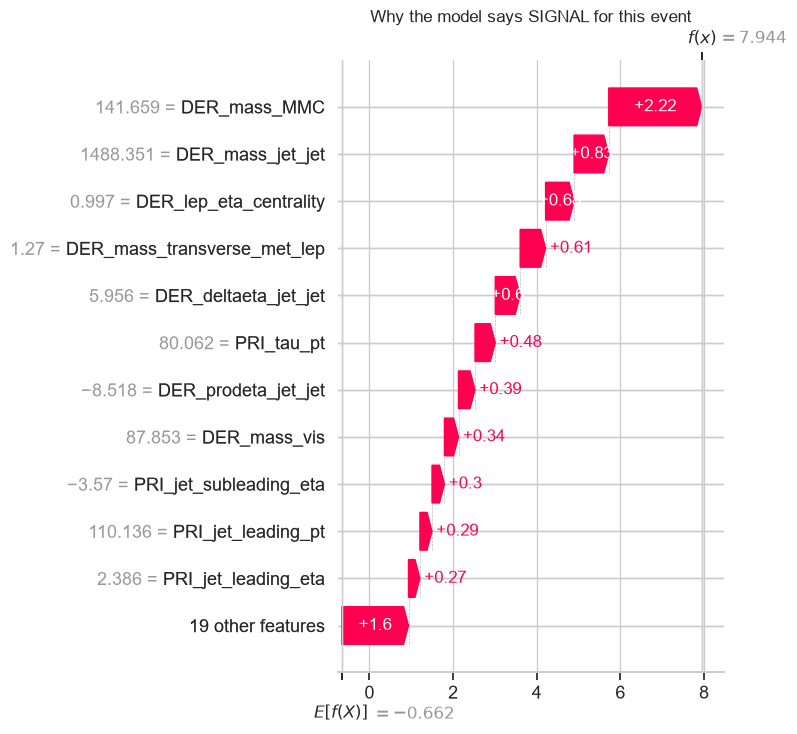

In [50]:
proba_shap = final_model.predict_proba(X_shap)[:, 1]
signal_pos = int(np.argmax(proba_shap))
event_id = X_shap.index[signal_pos]
print(f"Event {event_id}: P(signal) = {proba_shap[signal_pos]:.3f} | true label = {'signal' if y_test.loc[event_id] == 1 else 'background'}")

shap.plots.waterfall(shap_values[signal_pos], max_display=12, show=False)
plt.title("Why the model says SIGNAL for this event")
plt.tight_layout()
plt.show()

Event 95296: P(signal) = 0.001 | true label = background


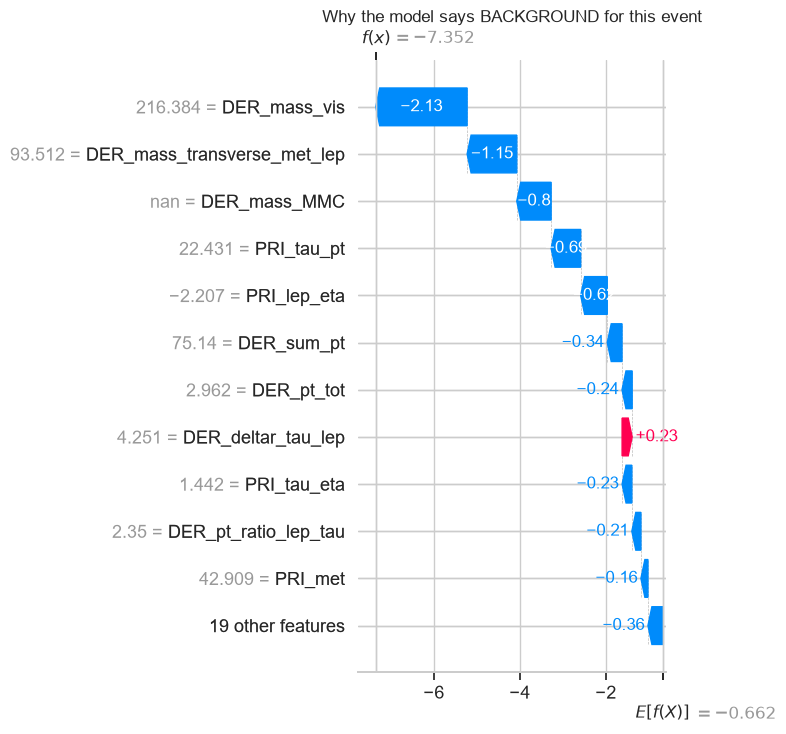

In [51]:
background_pos = int(np.argmin(proba_shap))
event_id = X_shap.index[background_pos]
print(f"Event {event_id}: P(signal) = {proba_shap[background_pos]:.3f} | true label = {'signal' if y_test.loc[event_id] == 1 else 'background'}")

shap.plots.waterfall(shap_values[background_pos], max_display=12, show=False)
plt.title("Why the model says BACKGROUND for this event")
plt.tight_layout()
plt.show()

### 7.7 What the model learned

- **`DER_mass_MMC` is the most important feature** by gain and by SHAP (mean |SHAP| = 0.92, almost double the next one).
- The SHAP dependence plot shows a **sharp peak around 125 GeV**, which is the mass of the Higgs boson: the model rediscovered the Higgs mass from the data alone.
- Events where `DER_mass_MMC` is **missing** (the column of points on the left of the plot) get SHAP values around -1 to -1.6, so missingness pushes the prediction towards background. This matches the EDA (only 7.4% signal when it is missing).
- `DER_mass_transverse_met_lep`: low values push towards signal, values around 60-100 push strongly towards background.
- The three built-in importance types disagree:
  - **weight** counts how often a feature is used, which favours continuous features used for many fine cuts;
  - **cover** favours jet features, whose splits (including where to send missing values) affect many events;
  - **gain** measures how much each split actually improves the loss, so it is the most meaningful one and it agrees with SHAP.
- Highly correlated features (e.g. `DER_mass_MMC` and `DER_mass_vis`, r = 0.91) **share importance**, so a feature can look less important than it really is.

## 8. Comparison with Other Algorithms

### 8.1 Logistic Regression (baseline)

In [52]:
results = []
times = {}

lr_model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=1000))
start = time.time()
lr_model.fit(X_train, y_train)
times["Logistic Regression"] = time.time() - start
results.append(evaluate(lr_model, X_test, y_test, "Logistic Regression"))
print(f"Logistic Regression trained in {times['Logistic Regression']:.1f} s")

Logistic Regression trained in 0.6 s


### 8.2 Random Forest

In [53]:
rf_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)
start = time.time()
rf_model.fit(X_train, y_train)          # sklearn's random forest also accepts NaN
times["Random Forest"] = time.time() - start
results.append(evaluate(rf_model, X_test, y_test, "Random Forest"))
print(f"Random Forest trained in {times['Random Forest']:.1f} s")

Random Forest trained in 14.3 s


### 8.3 sklearn GradientBoostingClassifier (classic boosting)

In [54]:
gb_model = make_pipeline(SimpleImputer(strategy="median"),
                         GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE))
start = time.time()
gb_model.fit(X_train, y_train)          # classic GBM cannot handle NaN, so we impute
times["sklearn GradientBoosting"] = time.time() - start
results.append(evaluate(gb_model, X_test, y_test, "sklearn GradientBoosting"))
print(f"sklearn GradientBoosting trained in {times['sklearn GradientBoosting']:.1f} s")

sklearn GradientBoosting trained in 354.6 s


In [55]:
xgb_same = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1)
start = time.time()
xgb_same.fit(X_train, y_train)
times["XGBoost (same settings as GBM)"] = time.time() - start
results.append(evaluate(xgb_same, X_test, y_test, "XGBoost (same settings as GBM)"))
print(f"XGBoost with the same 300 trees / depth 5 trained in {times['XGBoost (same settings as GBM)']:.1f} s")

XGBoost with the same 300 trees / depth 5 trained in 0.8 s


### 8.3b LightGBM
- Microsoft's gradient boosting library (2017), XGBoost's main competitor
- grows trees **leaf-wise** (always splits the best leaf) instead of level-wise, and also handles NaN natively
- same settings as above: 300 trees, depth 5, learning rate 0.1

In [56]:
lgbm_model = LGBMClassifier(n_estimators=300, max_depth=5, num_leaves=31, learning_rate=0.1,
                            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
start = time.time()
lgbm_model.fit(X_train, y_train)
times["LightGBM (same settings as GBM)"] = time.time() - start
results.append(evaluate(lgbm_model, X_test, y_test, "LightGBM (same settings as GBM)"))
print(f"LightGBM trained in {times['LightGBM (same settings as GBM)']:.1f} s")

LightGBM trained in 0.7 s


### 8.4 Results table
- ROC-AUC, accuracy, F1, training time

In [57]:
results.append(evaluate(final_model, X_test, y_test, "XGBoost tuned"))
times["XGBoost tuned"] = final_time

results_df = pd.DataFrame(results).set_index("model")
results_df["train_time_s"] = pd.Series(times)
results_df = results_df.sort_values("roc_auc", ascending=False)
results_df.round(4)

,accuracy,precision,recall,f1,roc_auc,train_time_s
model,,,,,,
XGBoost tuned,0.8431,0.7937,0.7328,0.7620,0.9108,5.3271
XGBoost (same settings as GBM),0.8430,0.7923,0.7344,0.7622,0.9097,0.8494
LightGBM (same settings as GBM),0.8430,0.7939,0.7319,0.7616,0.9095,0.7287
sklearn GradientBoosting,0.8414,0.7917,0.7289,0.7590,0.9086,354.6161
Random Forest,0.8383,0.7949,0.7119,0.7511,0.9052,14.3121
Logistic Regression,0.7499,0.6714,0.5289,0.5917,0.8119,0.6032


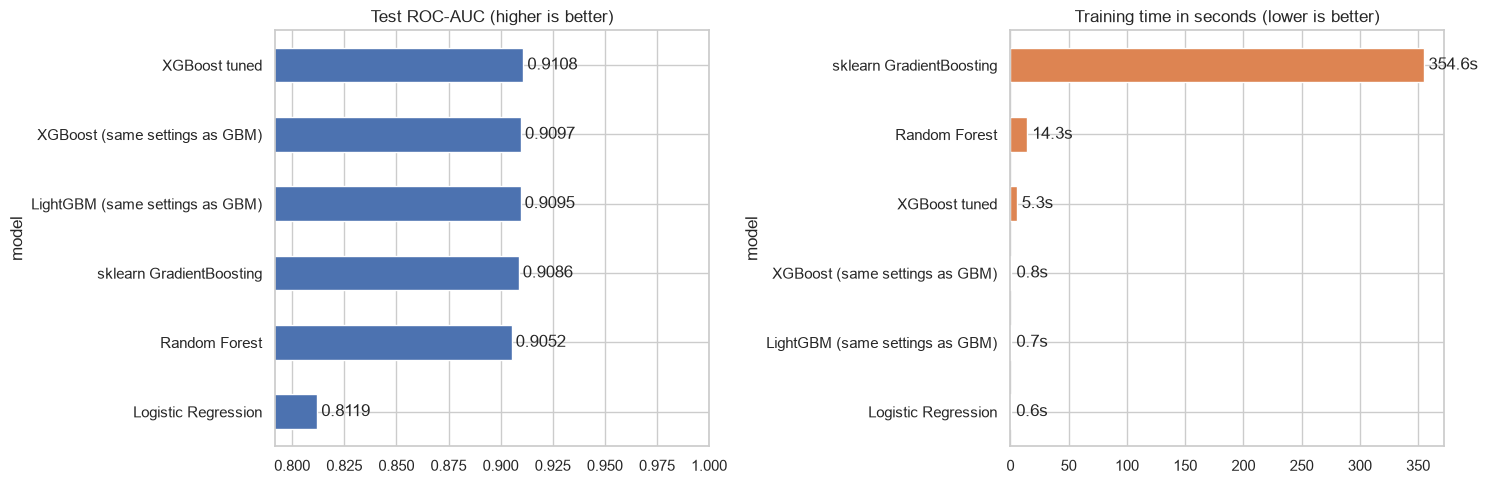

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
results_df["roc_auc"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_xlim(results_df["roc_auc"].min() - 0.02, 1)
axes[0].set_title("Test ROC-AUC (higher is better)")
for i, v in enumerate(results_df["roc_auc"].sort_values()):
    axes[0].text(v + 0.002, i, f"{v:.4f}", va="center")

results_df["train_time_s"].sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Training time in seconds (lower is better)")
for i, v in enumerate(results_df["train_time_s"].sort_values()):
    axes[1].text(v, i, f" {v:.1f}s", va="center")
plt.tight_layout()
plt.show()

### 8.5 Missing-value demo
- XGBoost with NaN vs with mean imputation

In [59]:
demo_params = {**final_params, "n_estimators": final_model.best_iteration + 1}

# (a) XGBoost with NaN: it learns the best direction for missing values
xgb_nan = XGBClassifier(**demo_params, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

# (b) XGBoost after mean imputation: the "missing" information is replaced by an average
imputer = SimpleImputer(strategy="mean").fit(X_train)
X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)
xgb_imp = XGBClassifier(**demo_params, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_imp, y_train)

missing_demo = pd.DataFrame([
    evaluate(xgb_nan, X_test, y_test, "XGBoost with NaN (native)"),
    evaluate(xgb_imp, X_test_imp, y_test, "XGBoost with mean imputation"),
]).set_index("model")
missing_demo.round(4)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
XGBoost with NaN (native),0.8431,0.7937,0.7328,0.762,0.9108
XGBoost with mean imputation,0.8414,0.7919,0.7287,0.759,0.9105


In [60]:
# where did the trees send missing DER_mass_MMC values? (first tree that splits on it)
trees = xgb_nan.get_booster().trees_to_dataframe()
mmc_splits = trees[trees["Feature"] == "DER_mass_MMC"]
first = mmc_splits.iloc[0]
direction = "Yes (< threshold) branch" if first["Missing"] == first["Yes"] else "No (>= threshold) branch"
print(f"Tree {first['Tree']}, split DER_mass_MMC < {first['Split']:.1f}: missing values go to the {direction}")
print(f"DER_mass_MMC is used in {len(mmc_splits):,} splits across all trees")

Tree 0, split DER_mass_MMC < 94.8: missing values go to the Yes (< threshold) branch
DER_mass_MMC is used in 2,138 splits across all trees


### 8.6 Comparison summary

| Model | Test ROC-AUC | Training time |
|-------|-------------|---------------|
| XGBoost tuned | **0.9108** | 5.3 s |
| XGBoost (same settings as GBM) | 0.9097 | 0.8 s |
| LightGBM (same settings as GBM) | 0.9095 | **0.7 s** |
| sklearn GradientBoosting | 0.9086 | 355 s |
| Random Forest | 0.9052 | 14.3 s |
| Logistic Regression | 0.8119 | 0.6 s |

- **Boosted trees vs a linear model:** Logistic Regression is about 0.10 AUC behind and finds only 52.9% of the signal (XGBoost: 73.3%). A straight line cannot model the "bump" of `DER_mass_MMC` around 125 GeV.
- **Boosting vs bagging:** Random Forest is fast and decent (0.9052) but stays below the boosting models.
- **Speed:** with the same 300 trees and depth 5, XGBoost trained in **under 1 second vs about 6 minutes** for sklearn's classic GradientBoosting, **hundreds of times faster**, with slightly better accuracy. This comes from histogram-based splits, multithreading, and not needing an imputation step. (Exact times change a little from run to run.)
- **XGBoost vs LightGBM:** with the same settings they are practically equal (0.9097 vs 0.9095) and both train in under a second. LightGBM is usually a bit faster on very large data because it grows trees leaf-wise, while XGBoost grows them level-wise.
- **Missing values:** native NaN handling (0.9108) and mean imputation (0.9105) give almost the same score here. Trees can partly recognise the repeated imputed value, so imputation does not destroy the information completely. The real advantage of the native approach is that it needs **no extra preprocessing step** and the model **learns where missing values should go**. For example, the first split on `DER_mass_MMC` sends missing values to the "< 94.8" branch, the same side as low, background-like masses.

### 8.7 Improving the model
- try 3 ways to beat the tuned model: feature engineering, feature selection, more data
- same test set as before, so the scores are comparable

#### 8.7.1 Feature engineering
- raw angles (`phi`) mean nothing alone: the detector is round, so the whole event can be rotated
- what matters is the **angle between** particles → `dphi_*` features
- detector is symmetric → use `|eta|`
- extra physics features: tau-lepton eta gap, tau-MET transverse mass, MET / sumET, number of missing values

In [61]:
PHI_COLS = ["PRI_tau_phi", "PRI_lep_phi", "PRI_met_phi", "PRI_jet_leading_phi", "PRI_jet_subleading_phi"]
ETA_COLS = ["PRI_tau_eta", "PRI_lep_eta", "PRI_jet_leading_eta", "PRI_jet_subleading_eta"]

def delta_phi(a, b):
    """Angle between two directions, wrapped into [0, pi]."""
    return np.abs((a - b + np.pi) % (2 * np.pi) - np.pi)

def add_features(X):
    X = X.copy()
    X["dphi_tau_lep"]   = delta_phi(X["PRI_tau_phi"], X["PRI_lep_phi"])
    X["dphi_tau_met"]   = delta_phi(X["PRI_tau_phi"], X["PRI_met_phi"])
    X["dphi_lep_met"]   = delta_phi(X["PRI_lep_phi"], X["PRI_met_phi"])
    X["dphi_tau_jet1"]  = delta_phi(X["PRI_tau_phi"], X["PRI_jet_leading_phi"])
    X["dphi_lep_jet1"]  = delta_phi(X["PRI_lep_phi"], X["PRI_jet_leading_phi"])
    X["dphi_jet1_jet2"] = delta_phi(X["PRI_jet_leading_phi"], X["PRI_jet_subleading_phi"])
    X["deta_tau_lep"]   = (X["PRI_tau_eta"] - X["PRI_lep_eta"]).abs()
    X["mt_tau_met"]     = np.sqrt(2 * X["PRI_tau_pt"] * X["PRI_met"] * (1 - np.cos(X["PRI_tau_phi"] - X["PRI_met_phi"])))
    X["met_over_sumet"] = X["PRI_met"] / X["PRI_met_sumet"]
    X["n_missing"]      = X.isna().sum(axis=1)
    for col in ETA_COLS:
        X[col] = X[col].abs()
    return X.drop(columns=PHI_COLS)          # raw angles are replaced by the differences

X_train_fe, X_val_fe, X_test_fe = add_features(X_train), add_features(X_val), add_features(X_test)
new_cols = [c for c in X_train_fe.columns if c not in X_train.columns]
print(f"Features: {X_train.shape[1]} -> {X_train_fe.shape[1]}")
print("New features:", new_cols)

Features: 30 -> 35
New features: ['dphi_tau_lep', 'dphi_tau_met', 'dphi_lep_met', 'dphi_tau_jet1', 'dphi_lep_jet1', 'dphi_jet1_jet2', 'deta_tau_lep', 'mt_tau_met', 'met_over_sumet', 'n_missing']


In [62]:
def train_improved(X_tr, y_tr, X_va, y_va, X_te, y_te, name, learning_rate=0.05, **changes):
    """Train XGBoost with the tuned parameters + early stopping, return (model, metrics row)."""
    params = {**best_params, **changes, "learning_rate": learning_rate, "n_estimators": 5000}
    model = XGBClassifier(**params, early_stopping_rounds=100, eval_metric="logloss",
                          random_state=RANDOM_STATE, n_jobs=-1)
    start = time.time()
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    row = evaluate(model, X_te, y_te, name)
    row.update(n_features=X_tr.shape[1], n_train_rows=len(X_tr), n_trees=model.best_iteration + 1,
               train_time_s=time.time() - start)
    print(f"{name:40s} ROC-AUC = {row['roc_auc']:.4f}")
    return model, row

improve_rows = []
_, row = train_improved(X_train, y_train, X_val, y_val, X_test, y_test, "baseline (30 original features)")
improve_rows.append(row)
fe_model, row = train_improved(X_train_fe, y_train, X_val_fe, y_val, X_test_fe, y_test, "+ feature engineering")
improve_rows.append(row)

baseline (30 original features)          ROC-AUC = 0.9108
+ feature engineering                    ROC-AUC = 0.9115


#### 8.7.2 Feature selection
- rank the features by mean |SHAP| (computed on the **validation** set, so the test set stays untouched)
- keep only the top k features and check whether the score drops

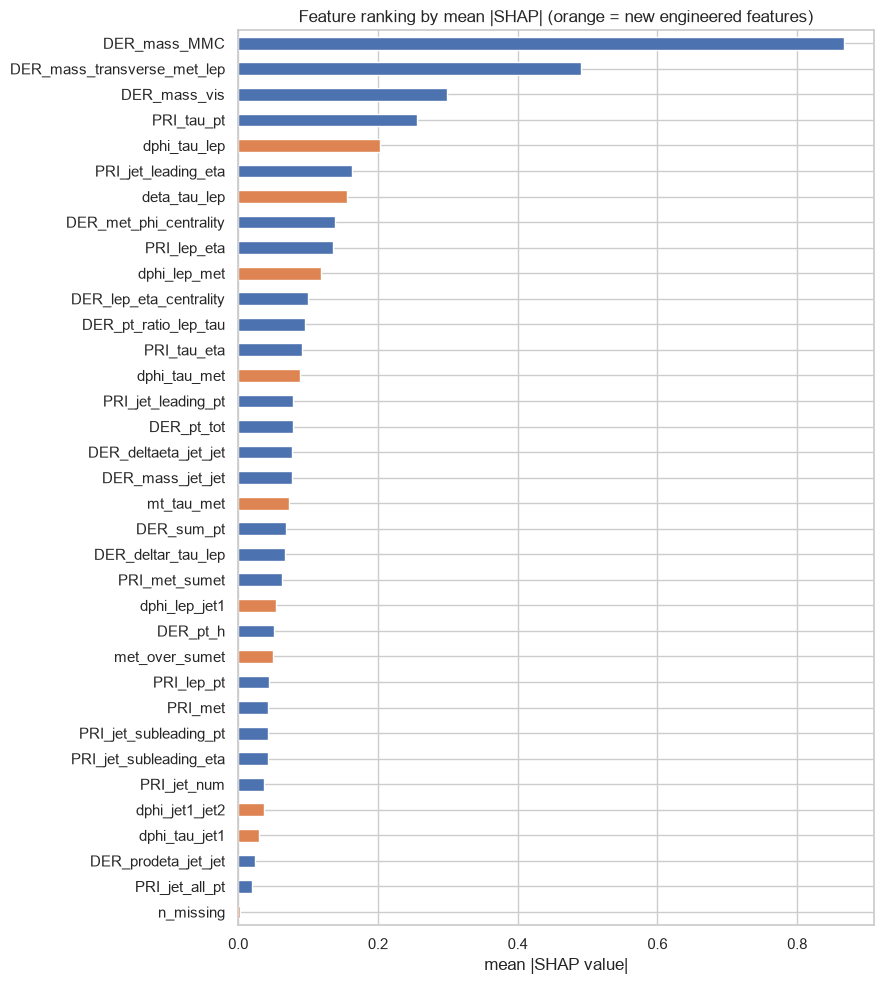

In [63]:
shap_fe = shap.TreeExplainer(fe_model)(X_val_fe.sample(5000, random_state=RANDOM_STATE))
shap_rank = pd.Series(np.abs(shap_fe.values).mean(axis=0), index=X_train_fe.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
colors = ["#DD8452" if c in new_cols else "#4C72B0" for c in shap_rank.index[::-1]]
shap_rank[::-1].plot.barh(color=colors, ax=ax)
ax.set_title("Feature ranking by mean |SHAP| (orange = new engineered features)")
ax.set_xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

In [64]:
selection_rows = []
for k in [35, 30, 25, 20, 15]:
    cols = shap_rank.index[:k]
    _, row = train_improved(X_train_fe[cols], y_train, X_val_fe[cols], y_val, X_test_fe[cols], y_test, f"top {k} features")
    selection_rows.append(row)

selection_df = pd.DataFrame(selection_rows).set_index("model")[["n_features", "roc_auc", "accuracy", "n_trees", "train_time_s"]]
selection_df.round(4)

top 35 features                          ROC-AUC = 0.9120
top 30 features                          ROC-AUC = 0.9114
top 25 features                          ROC-AUC = 0.9111
top 20 features                          ROC-AUC = 0.9098
top 15 features                          ROC-AUC = 0.9058


,n_features,roc_auc,accuracy,n_trees,train_time_s
model,,,,,
top 35 features,35,0.9120,0.8435,626,4.0785
top 30 features,30,0.9114,0.8422,522,3.3434
top 25 features,25,0.9111,0.8426,443,2.6360
top 20 features,20,0.9098,0.8411,533,2.6968
top 15 features,15,0.9058,0.8364,520,2.3247


In [65]:
selected_cols = list(shap_rank.index[:25])
dropped = [c for c in shap_rank.index if c not in selected_cols]
print(f"Keeping {len(selected_cols)} features, dropping {len(dropped)}: {dropped}")

_, row = train_improved(X_train_fe[selected_cols], y_train, X_val_fe[selected_cols], y_val,
                        X_test_fe[selected_cols], y_test, "+ FE + selection (top 25)")
improve_rows.append(row)

Keeping 25 features, dropping 10: ['PRI_lep_pt', 'PRI_met', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_num', 'dphi_jet1_jet2', 'dphi_tau_jet1', 'DER_prodeta_jet_jet', 'PRI_jet_all_pt', 'n_missing']
+ FE + selection (top 25)                ROC-AUC = 0.9111


#### 8.7.3 More training data
- the file has 568,238 more labelled events (the old Kaggle leaderboard rows, `KaggleSet` b / v / u)
- added to the **training set only**; validation and test sets are unchanged
- also try a lower learning rate and deeper trees, since more data can support a bigger model

In [66]:
extra = df_all[df_all["KaggleSet"] != "t"]
print(f"Overlap with our 250k events: {extra['EventId'].isin(df['EventId']).sum()} events")

y_extra = (extra["Label"] == "s").astype(int)
X_extra = add_features(extra.drop(columns=drop_cols + ["Label"]).replace(-999, np.nan))

X_big = pd.concat([X_train_fe, X_extra])
y_big = pd.concat([y_train, y_extra])
print(f"Training rows: {len(X_train_fe):,} -> {len(X_big):,}")

Overlap with our 250k events: 0 events
Training rows: 175,000 -> 743,238


In [67]:
_, row = train_improved(X_big, y_big, X_val_fe, y_val, X_test_fe, y_test, "+ FE + extra data")
improve_rows.append(row)

_, row = train_improved(X_big, y_big, X_val_fe, y_val, X_test_fe, y_test,
                        "+ FE + extra data + lr 0.02, depth 8", learning_rate=0.02, max_depth=8)
improve_rows.append(row)

+ FE + extra data                        ROC-AUC = 0.9138
+ FE + extra data + lr 0.02, depth 8     ROC-AUC = 0.9140


#### 8.7.4 Results

In [68]:
improve_df = pd.DataFrame(improve_rows).set_index("model")
improve_df["gain_vs_baseline"] = improve_df["roc_auc"] - improve_df["roc_auc"].iloc[0]
improve_df[["n_features", "n_train_rows", "roc_auc", "gain_vs_baseline", "accuracy", "f1", "n_trees", "train_time_s"]].round(4)

,n_features,n_train_rows,roc_auc,gain_vs_baseline,accuracy,f1,n_trees,train_time_s
model,,,,,,,,
baseline (30 original features),30,175000,0.9108,0.0000,0.8431,0.7620,778,4.4798
+ feature engineering,35,175000,0.9115,0.0006,0.8431,0.7623,595,3.8667
+ FE + selection (top 25),25,175000,0.9111,0.0003,0.8426,0.7615,443,2.6291
+ FE + extra data,35,743238,0.9138,0.0030,0.8443,0.7633,887,21.3491
"+ FE + extra data + lr 0.02, depth 8",35,743238,0.9140,0.0032,0.8447,0.7640,1217,36.0308


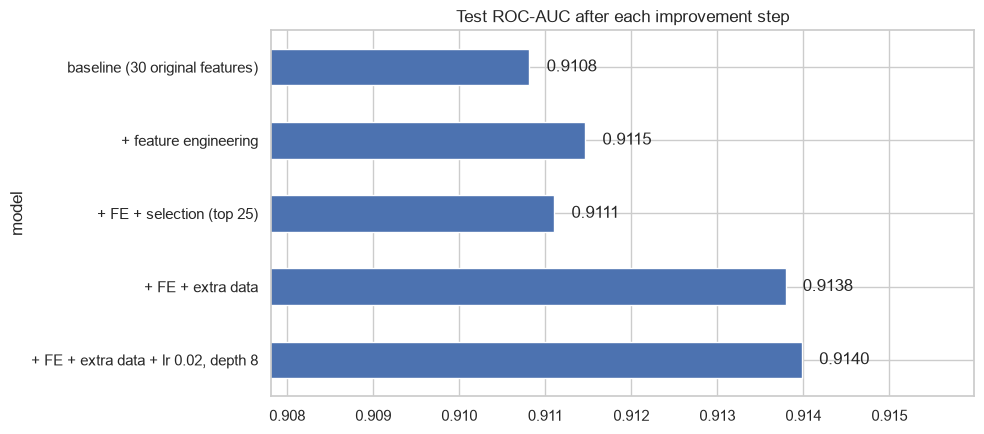

In [69]:
fig, ax = plt.subplots(figsize=(10, 4.5))
improve_df["roc_auc"][::-1].plot.barh(color="#4C72B0", ax=ax)
ax.set_xlim(improve_df["roc_auc"].min() - 0.003, improve_df["roc_auc"].max() + 0.002)
for i, v in enumerate(improve_df["roc_auc"][::-1]):
    ax.text(v + 0.0002, i, f"{v:.4f}", va="center")
ax.set_title("Test ROC-AUC after each improvement step")
plt.tight_layout()
plt.show()

#### 8.7.5 Improvement summary

| Step | Test ROC-AUC | Gain |
|------|-------------|------|
| Baseline (30 original features) | 0.9108 | - |
| + feature engineering (35 features) | 0.9115 | +0.0006 |
| + FE + selection (top 25 features) | 0.9111 | +0.0003 |
| + FE + 568k extra training rows | 0.9138 | +0.0030 |
| + FE + extra data + lr 0.02, depth 8 | 0.9140 | +0.0032 |

- **Feature engineering** gives a small gain. `dphi_tau_lep` (angle between tau and lepton) becomes one of the top features, so the physics idea is right, but the `DER_` features already contain most of this information.
- **Feature selection** does not improve the score, but about 10 features (the raw angles and the weakest ones) can be removed **at no cost**, giving a simpler and faster model. Below about 20 features the score starts to fall.
- **More training data is the biggest win**, larger than any feature or tuning change.
- **Bigger model + lower learning rate** adds very little for 2-3x the training time.
- The same 35 features in a different column order scored 0.9120 instead of 0.9115, which shows the noise level: differences below about 0.001 AUC are within run-to-run noise. We are close to the limit of this data, because some signal and background events are physically identical.
- **Lesson: more data > feature engineering > more tuning.**

### 8.8 Bonus: XGBoost for regression
- same algorithm, different objective: `reg:squarederror`, so **g = ŷ − y and h = 1** (instead of p − y and p(1 − p))
- task: estimate the particle mass `DER_mass_MMC` from the 17 raw `PRI_` detector measurements
- physicists compute this mass with a complex algorithm: can XGBoost learn it from the raw data?
- rows where the mass is missing are removed (there is no target for them)
- metrics: MAE, MSE, RMSE, R²

In [70]:
reg_data = df[df["DER_mass_MMC"] != -999]
X_reg = reg_data[pri_cols].replace(-999, np.nan)
y_reg = reg_data["DER_mass_MMC"]

X_reg_temp, X_reg_test, y_reg_temp, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.15, random_state=RANDOM_STATE)
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(X_reg_temp, y_reg_temp, test_size=0.15 / 0.85, random_state=RANDOM_STATE)
print(f"Rows: train {len(X_reg_train):,} | validation {len(X_reg_val):,} | test {len(X_reg_test):,}")
print(f"Target: mean {y_reg.mean():.1f} GeV, median {y_reg.median():.1f} GeV, std {y_reg.std():.1f} GeV")

Rows: train 148,320 | validation 31,783 | test 31,783
Target: mean 121.9 GeV, median 112.4 GeV, std 57.3 GeV


In [71]:
def regression_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    return {"model": name, "MAE": mean_absolute_error(y_true, y_pred), "MSE": mse,
            "RMSE": np.sqrt(mse), "R2": r2_score(y_true, y_pred)}

reg_rows = [regression_metrics(y_reg_test, np.full(len(y_reg_test), y_reg_train.mean()), "baseline: always predict the mean")]

lin_reg = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LinearRegression())
lin_reg.fit(X_reg_train, y_reg_train)
reg_rows.append(regression_metrics(y_reg_test, lin_reg.predict(X_reg_test), "Linear Regression"))

xgb_reg = XGBRegressor(objective="reg:squarederror", n_estimators=3000, learning_rate=0.05, max_depth=8,
                       subsample=0.8, colsample_bytree=0.8, early_stopping_rounds=100,
                       random_state=RANDOM_STATE, n_jobs=-1)
start = time.time()
xgb_reg.fit(X_reg_train, y_reg_train, eval_set=[(X_reg_val, y_reg_val)], verbose=False)
print(f"XGBoost regressor: {xgb_reg.best_iteration + 1} trees, trained in {time.time() - start:.1f} s")
reg_rows.append(regression_metrics(y_reg_test, xgb_reg.predict(X_reg_test), "XGBoost regressor"))

reg_results = pd.DataFrame(reg_rows).set_index("model")
reg_results.round(3)

XGBoost regressor: 2998 trees, trained in 15.4 s


,MAE,MSE,RMSE,R2
model,,,,
baseline: always predict the mean,34.720,3374.572,58.091,-0.000
Linear Regression,29.161,2554.535,50.542,0.243
XGBoost regressor,8.429,283.985,16.852,0.916


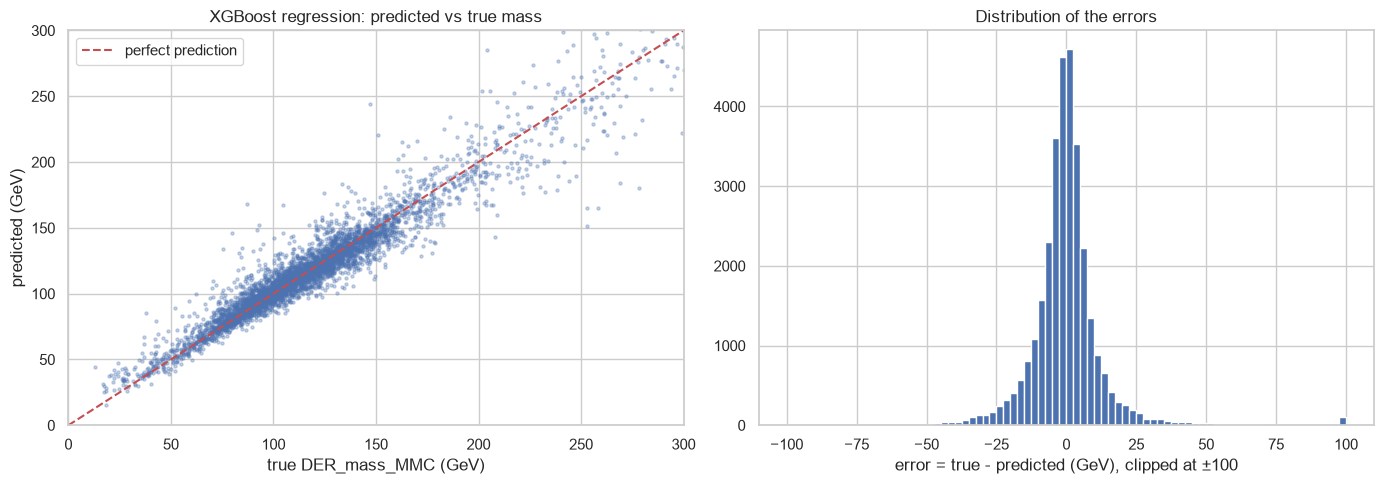

In [72]:
y_reg_pred = xgb_reg.predict(X_reg_test)
sample = np.random.RandomState(RANDOM_STATE).choice(len(y_reg_test), 5000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_reg_test.to_numpy()[sample], y_reg_pred[sample], s=5, alpha=0.3)
axes[0].plot([0, 300], [0, 300], "r--", label="perfect prediction")
axes[0].set_xlim(0, 300)
axes[0].set_ylim(0, 300)
axes[0].set_xlabel("true DER_mass_MMC (GeV)")
axes[0].set_ylabel("predicted (GeV)")
axes[0].set_title("XGBoost regression: predicted vs true mass")
axes[0].legend()

residuals = y_reg_test.to_numpy() - y_reg_pred
axes[1].hist(np.clip(residuals, -100, 100), bins=80, color="#4C72B0")
axes[1].set_xlabel("error = true - predicted (GeV), clipped at ±100")
axes[1].set_title("Distribution of the errors")
plt.tight_layout()
plt.show()

**What the regression shows**

| Model | MAE (GeV) | RMSE (GeV) | R² |
|-------|-----------|------------|----|
| Always predict the mean | 34.7 | 58.1 | 0.00 |
| Linear Regression | 29.2 | 50.5 | 0.24 |
| **XGBoost regressor** | **8.4** | **16.9** | **0.92** |

- XGBoost explains **92% of the variance** of the mass from the raw measurements, while Linear Regression explains only 24%. The relationship between the raw measurements and the mass is strongly non-linear.
- On average the prediction is **8.4 GeV** away from the physicists' value.
- RMSE (16.9) is much larger than MAE (8.4) because a few events with very large masses (long tail) produce big errors, and squared errors punish those heavily.
- The model used 2,998 of the 3,000 allowed trees, so it was still improving slowly. More trees or a higher learning rate could reduce the error a little more.
- **Same algorithm, different loss:** only g and h changed (g = ŷ − y, h = 1), and the trees, splits and gain formula stayed exactly the same.

### 8.9 Save and reload the model
- a trained model can be saved to a file and reused later without retraining
- the JSON format is readable and works across XGBoost versions

In [73]:
MODEL_PATH = "xgb_higgs_model.json"
final_model.save_model(MODEL_PATH)

loaded_model = XGBClassifier()
loaded_model.load_model(MODEL_PATH)
same = np.allclose(loaded_model.predict_proba(X_test)[:, 1], y_proba)
print(f"Saved to {MODEL_PATH} ({os.path.getsize(MODEL_PATH) / 1e6:.1f} MB)")
print(f"Predictions identical after reloading: {same}")

Saved to xgb_higgs_model.json (4.5 MB)
Predictions identical after reloading: True


## 9. Conclusions

### 9.1 What we learned

- XGBoost builds trees **one after another**, each one correcting the errors of the previous ones, using the gradient (g) and hessian (h) of the loss.
- On the Higgs data it reached a **test ROC-AUC of 0.911** and 84.3% accuracy.
- EDA mattered: it showed that -999 means "missing", that the missingness itself is informative, and that the relationships are non-linear. Each of these points to a tree-based model.
- Good defaults plus early stopping already give most of the performance. Tuning added a smaller improvement.
- SHAP made the model explainable: it showed that the model learned the Higgs mass peak at 125 GeV.
- Checking the theory by hand worked: in 7.5 our formula **−G/(H+λ)** gave exactly the same leaf values, and our gain formula gave exactly the same gain, as XGBoost.
- The same algorithm also does **regression** by changing only the loss (R² = 0.92 when predicting the particle mass).
- The decision threshold depends on the goal: 0.35 for the best F1, but 0.86 for the physicists' AMS metric.

### 9.2 Model strengths

- **Accuracy:** best ROC-AUC of all the models we compared.
- **Speed:** hundreds of times faster than sklearn's classic gradient boosting with the same settings, and as fast as LightGBM.
- **Missing values:** handled natively, with no imputation needed.
- **No scaling or heavy preprocessing:** we only replaced -999 and encoded the target.
- **Non-linear patterns and interactions** (like the mass peak) are learned automatically.
- **Built-in regularization and early stopping** keep overfitting under control (train/test gap 0.027).
- **Interpretable** with gain importance and SHAP.
- **Flexible:** the same tool handles classification and regression (R² = 0.92 on the mass task).

### 9.3 Model weaknesses

- **Many hyperparameters:** tuning takes time and the improvement can be small (+0.0045 AUC here).
- **Can overfit:** without early stopping the training loss keeps falling while validation does not improve.
- **Not directly interpretable:** a model of 778 trees needs extra tools (SHAP) to explain it.
- **Built-in importance types disagree**, and correlated features share importance, so importance plots can mislead.
- **Signal recall of 73%:** a quarter of Higgs events are still missed.

### 9.4 Possible improvements

- Feature engineering, feature selection and extra data were tested in 8.7 (ROC-AUC 0.911 → 0.914).
- Use Bayesian optimisation (e.g. Optuna) instead of random search, tuned on the full training set.
- Move the decision threshold, or use `scale_pos_weight`, to catch more signal events.
- Train with the competition `Weight` column as sample weights and evaluate with the official AMS metric.
- Compare with LightGBM and CatBoost, or combine several models (ensembling).
- Train on a GPU (`device="cuda"`) to make larger searches affordable.

## 10. References
- Chen & Guestrin (2016), XGBoost: A Scalable Tree Boosting System, KDD
- ATLAS collaboration (2014), Higgs Boson ML Challenge dataset, CERN Open Data
- XGBoost documentation: xgboost.readthedocs.io
- Ke et al. (2017), LightGBM: A Highly Efficient Gradient Boosting Decision Tree, NeurIPS
- Lundberg & Lee (2017), A Unified Approach to Interpreting Model Predictions (SHAP), NeurIPS
- Adam-Bourdarios et al. (2014), The Higgs boson machine learning challenge (AMS metric), JMLR Workshop and Conference Proceedings 42
- CERN Open Data record 328: https://opendata.cern.ch/record/328